# TFG — EDA completo
**Bloques:** A (calidad) · B (master_diario) · C (master_mensual) · D (gtrends) · E (encuesta) · F (modelos — plantillas)

**Archivos necesarios en `/content/`:** `master_diario.csv`, `master_mensual.csv`, `gtrends_clean.csv`, `encuesta_clean_tfg.csv`

Todos los gráficos se guardan en `/content/graficas_tfg/` y al final se comprimen en un ZIP.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, zipfile
warnings.filterwarnings('ignore')

# ── Carpeta de salida ─────────────────────────────────────────────────────────
OUT = '/content/graficas_tfg'
os.makedirs(OUT, exist_ok=True)

# ── Estilo global ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'font.size': 8.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
C1, C2, C3, C4 = '#2563EB', '#16A34A', '#DC2626', '#9333EA'
CGRIS = '#6B7280'
MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
DIAS  = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

def save(fig, name):
    path = f'{OUT}/{name}.png'
    fig.savefig(path, bbox_inches='tight', dpi=120)
    plt.show()
    print(f'  ✓ {name}.png')

print('Setup OK — gráficos se guardarán en:', OUT)

Setup OK — gráficos se guardarán en: /content/graficas_tfg


In [2]:
# ── Carga de datasets ─────────────────────────────────────────────────────────
md  = pd.read_csv('/content/master_diario.csv',  parse_dates=['fecha'])
mm  = pd.read_csv('/content/master_mensual.csv')
gt  = pd.read_csv('/content/gtrends_clean.csv',  parse_dates=['fecha'])
enc = pd.read_csv('/content/encuesta_clean_tfg.csv')

# ── Preparación puntual (sin modificar datasets originales) ───────────────────
# pct_remontes tiene 32 filas con valor >1 (error de fuente: remontes_abiertos > remontes_total)
# Se clampean a 1 en las vistas de análisis, no en el dataset
md_w = md.copy()  # working copy para gráficos
for col in ['pct_remontes_abiertos','pct_pistas_abiertas','pct_km_abiertos']:
    if col in md_w.columns:
        md_w[col] = md_w[col].clip(upper=1.0)

mm_w = mm.copy()
for col in ['pct_remontes_med','pct_pistas_med','pct_km_med']:
    if col in mm_w.columns:
        mm_w[col] = mm_w[col].clip(upper=1.0)

# Filtro 2018-2025 para análisis principal (alineado con hoteles/gtrends)
md18 = md_w[md_w['anio'] >= 2018].copy()
# Solo días abiertos (para no sesgar medias con ceros estructurales)
abiertos = md18[md18['estado_abierta'] == 1].copy()

print(f'master_diario  : {md.shape[0]:,} × {md.shape[1]}  |  {md["estacion"].nunique()} estaciones')
print(f'master_mensual : {mm.shape[0]:,} × {mm.shape[1]}  |  {mm["estacion"].nunique()} estaciones')
print(f'gtrends        : {gt.shape}')
print(f'encuesta       : {enc.shape}')

master_diario  : 142,893 × 44  |  30 estaciones
master_mensual : 2,790 × 37  |  30 estaciones
gtrends        : (96, 16)
encuesta       : (224, 45)


---
## BLOQUE A — Calidad del dato

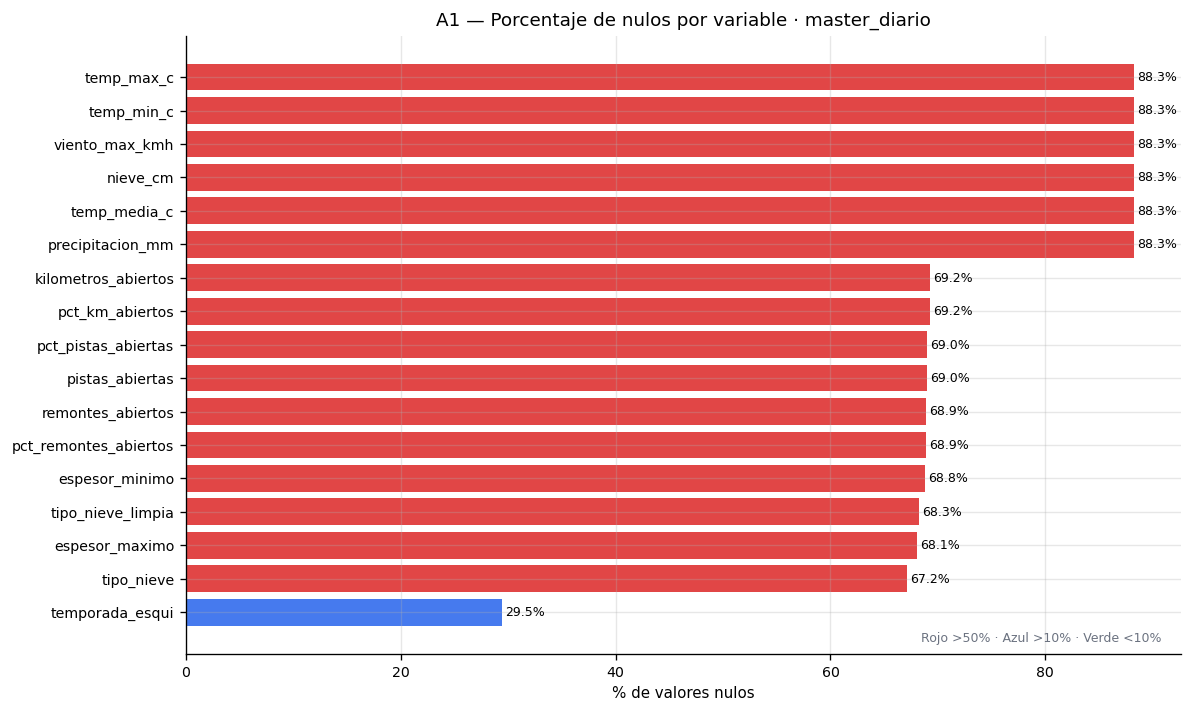

  ✓ A1_nulos_master_diario.png


In [3]:
# A1 — Porcentaje de nulos por variable en master_diario ──────────────────────
nulos_d = (md.isna().mean() * 100).sort_values(ascending=False)
nulos_d = nulos_d[nulos_d > 0]

fig, ax = plt.subplots(figsize=(10, 6))
colores = [C3 if v > 50 else C1 if v > 10 else C2 for v in nulos_d.values]
ax.barh(nulos_d.index[::-1], nulos_d.values[::-1], color=colores[::-1], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.5)
for i, v in enumerate(nulos_d.values[::-1]):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=7.5)
ax.set_xlabel('% de valores nulos')
ax.set_title('A1 — Porcentaje de nulos por variable · master_diario')
ax.text(0.98, 0.02, 'Rojo >50% · Azul >10% · Verde <10%',
        transform=ax.transAxes, ha='right', fontsize=7.5, color=CGRIS)
plt.tight_layout()
save(fig, 'A1_nulos_master_diario')

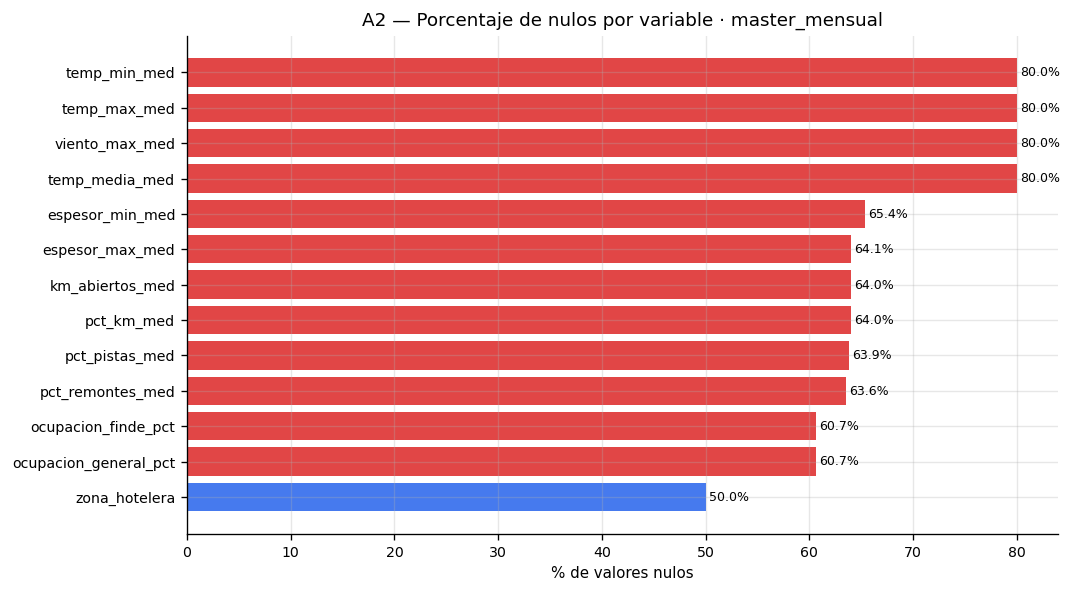

  ✓ A2_nulos_master_mensual.png


In [4]:
# A2 — Porcentaje de nulos por variable en master_mensual ─────────────────────
nulos_m = (mm.isna().mean() * 100).sort_values(ascending=False)
nulos_m = nulos_m[nulos_m > 0]

fig, ax = plt.subplots(figsize=(9, 5))
colores = [C3 if v > 50 else C1 if v > 10 else C2 for v in nulos_m.values]
ax.barh(nulos_m.index[::-1], nulos_m.values[::-1], color=colores[::-1], alpha=0.85)
for i, v in enumerate(nulos_m.values[::-1]):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=7.5)
ax.set_xlabel('% de valores nulos')
ax.set_title('A2 — Porcentaje de nulos por variable · master_mensual')
plt.tight_layout()
save(fig, 'A2_nulos_master_mensual')

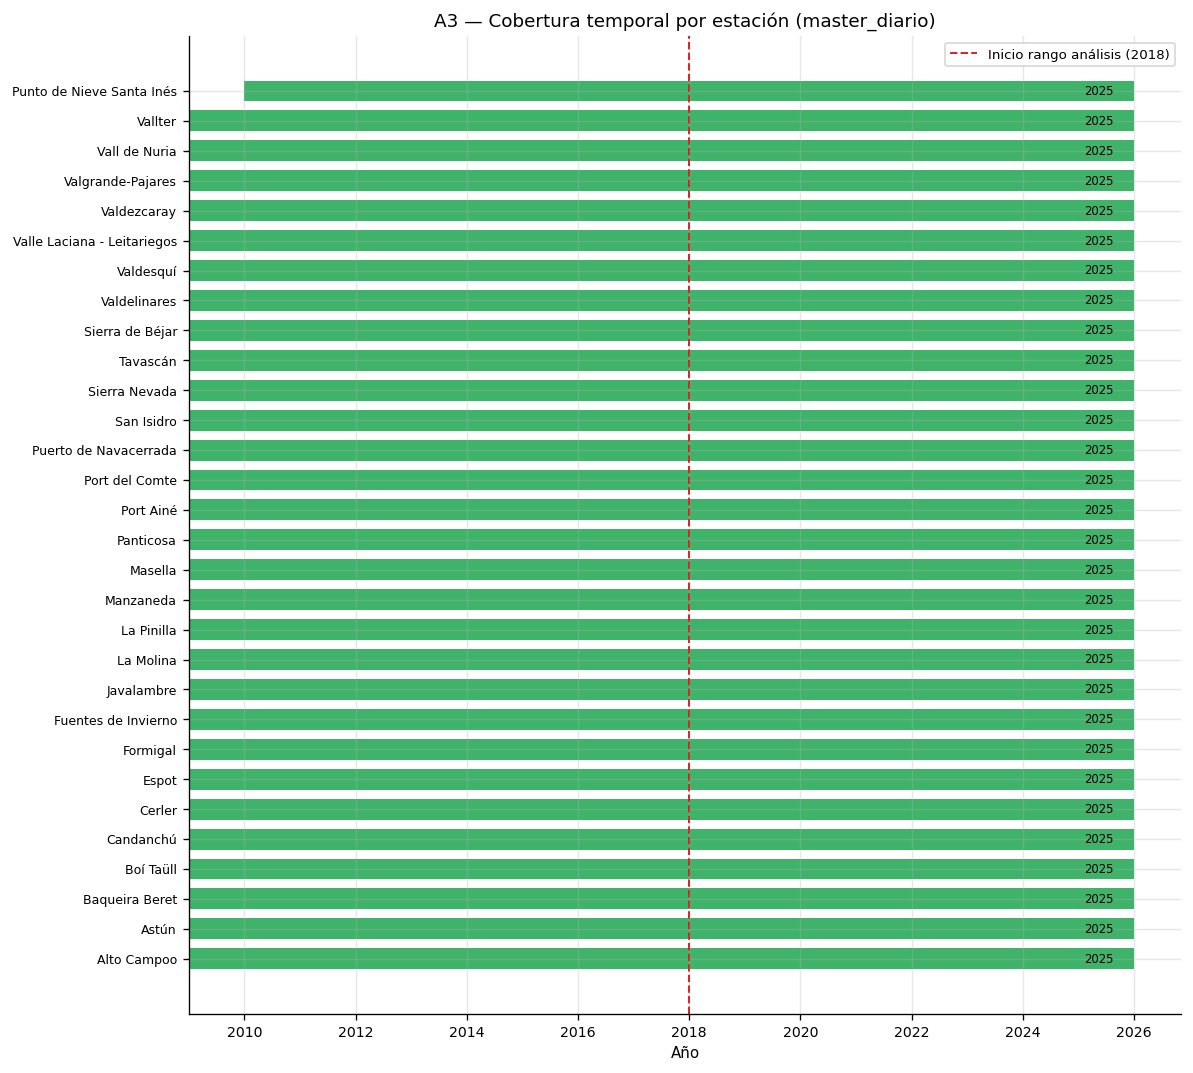

  ✓ A3_cobertura_temporal.png


In [5]:
# A3 — Cobertura temporal por estación ────────────────────────────────────────
# Para cada estación: primer y último año con datos en infonieve
cobertura = md.groupby('estacion')['anio'].agg(['min','max']).reset_index()
cobertura['n_anios'] = cobertura['max'] - cobertura['min'] + 1
cobertura = cobertura.sort_values('min')

fig, ax = plt.subplots(figsize=(10, 9))
for i, row in enumerate(cobertura.itertuples()):
    color = C2 if row.min <= 2012 else C1 if row.min <= 2016 else C4
    ax.barh(i, row.max - row.min + 1, left=row.min, color=color, alpha=0.82, height=0.7)
    ax.text(row.max + 0.1, i, str(row.max), va='center', fontsize=7)
ax.set_yticks(range(len(cobertura)))
ax.set_yticklabels(cobertura['estacion'], fontsize=7.5)
ax.set_xlabel('Año')
ax.set_title('A3 — Cobertura temporal por estación (master_diario)')
ax.axvline(2018, color=C3, linestyle='--', linewidth=1.2, label='Inicio rango análisis (2018)')
ax.legend(fontsize=8)
plt.tight_layout()
save(fig, 'A3_cobertura_temporal')

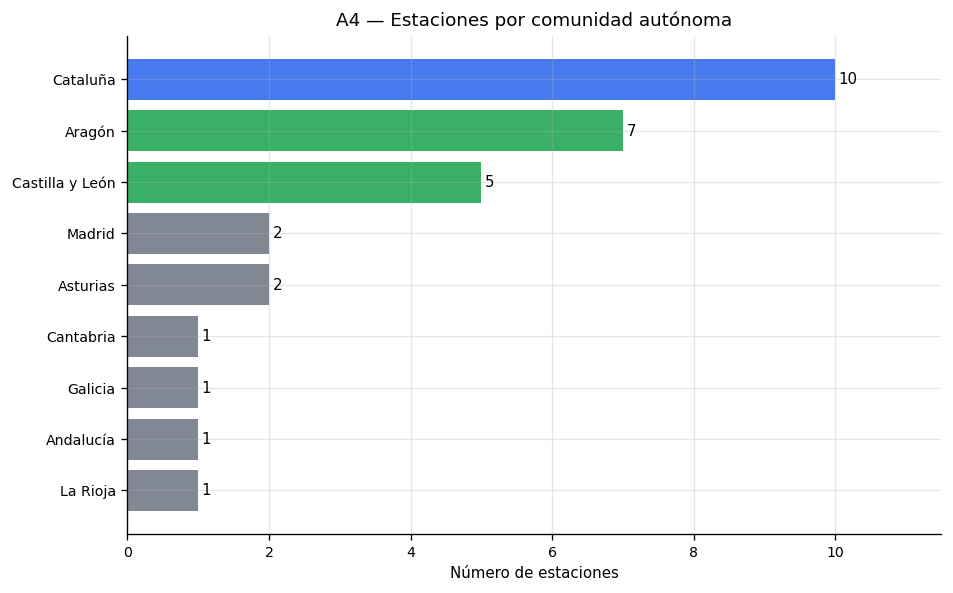

  ✓ A4_estaciones_por_comunidad.png


In [6]:
# A4 — Distribución de estaciones por comunidad autónoma ──────────────────────
est_static = md[['estacion','comunidad','orientacion','altitud_base_m',
                  'altitud_cima_m','desnivel_m','umbria']].drop_duplicates('estacion')
n_com = est_static['comunidad'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colores_com = [C1 if v == n_com.max() else C2 if v >= 3 else CGRIS for v in n_com.values]
ax.barh(n_com.index[::-1], n_com.values[::-1], color=colores_com[::-1], alpha=0.85)
for i, v in enumerate(n_com.values[::-1]):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9)
ax.set_xlabel('Número de estaciones')
ax.set_title('A4 — Estaciones por comunidad autónoma')
ax.set_xlim(0, n_com.max() + 1.5)
plt.tight_layout()
save(fig, 'A4_estaciones_por_comunidad')

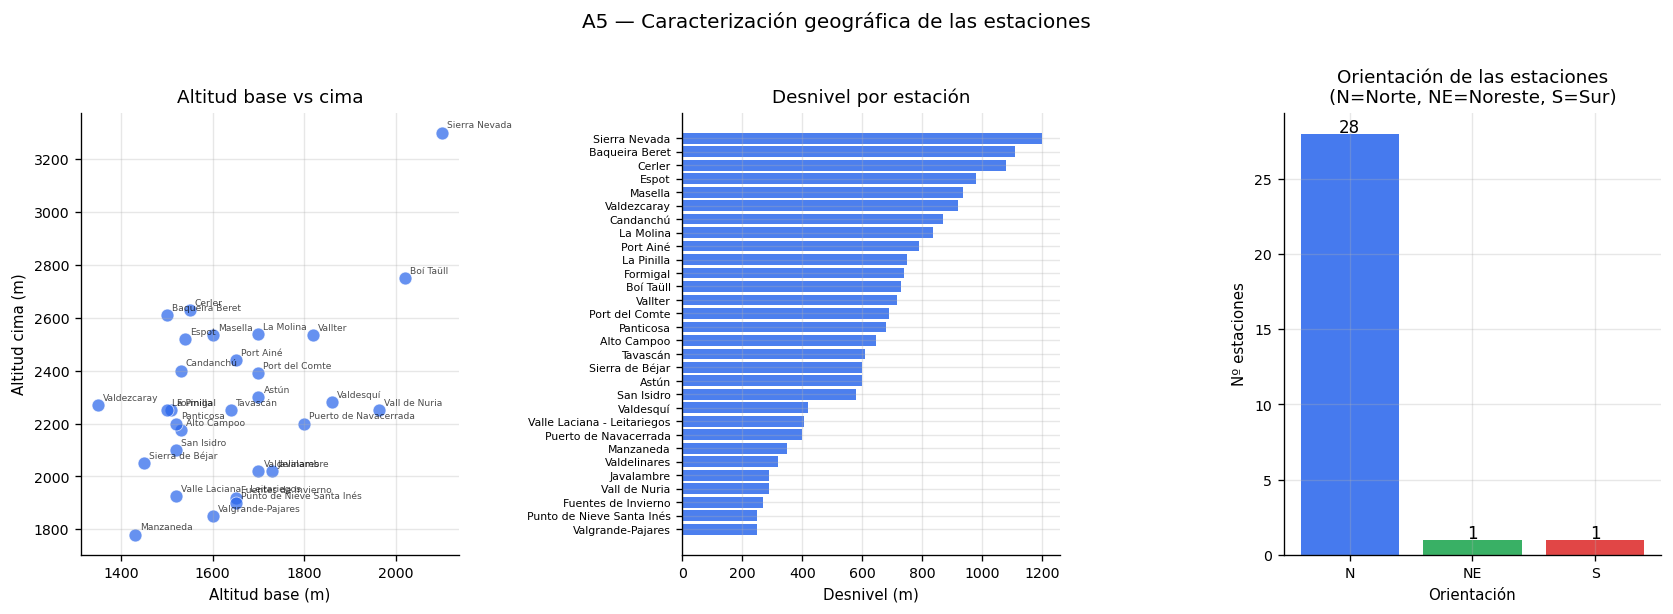

  ✓ A5_caracterizacion_geografica.png


In [7]:
# A5 — Caracterización geográfica: altitud y orientación ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Altitud base vs cima
axes[0].scatter(est_static['altitud_base_m'], est_static['altitud_cima_m'],
                color=C1, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
for _, row in est_static.iterrows():
    axes[0].annotate(row['estacion'], (row['altitud_base_m'], row['altitud_cima_m']),
                     fontsize=5.5, alpha=0.7,
                     xytext=(3, 3), textcoords='offset points')
axes[0].set_xlabel('Altitud base (m)')
axes[0].set_ylabel('Altitud cima (m)')
axes[0].set_title('Altitud base vs cima')

# Desnivel
desnivel_s = est_static.set_index('estacion')['desnivel_m'].sort_values()
axes[1].barh(desnivel_s.index, desnivel_s.values, color=C1, alpha=0.82)
axes[1].set_xlabel('Desnivel (m)')
axes[1].set_title('Desnivel por estación')
axes[1].tick_params(axis='y', labelsize=6.5)

# Orientación
ori_count = est_static['orientacion'].value_counts()
axes[2].bar(ori_count.index, ori_count.values, color=[C1, C2, C3][:len(ori_count)], alpha=0.85)
for i, v in enumerate(ori_count.values):
    axes[2].text(i, v + 0.1, str(v), ha='center', fontsize=10)
axes[2].set_xlabel('Orientación')
axes[2].set_ylabel('Nº estaciones')
axes[2].set_title('Orientación de las estaciones\n(N=Norte, NE=Noreste, S=Sur)')

plt.suptitle('A5 — Caracterización geográfica de las estaciones', fontsize=12, y=1.01)
plt.tight_layout()
save(fig, 'A5_caracterizacion_geografica')

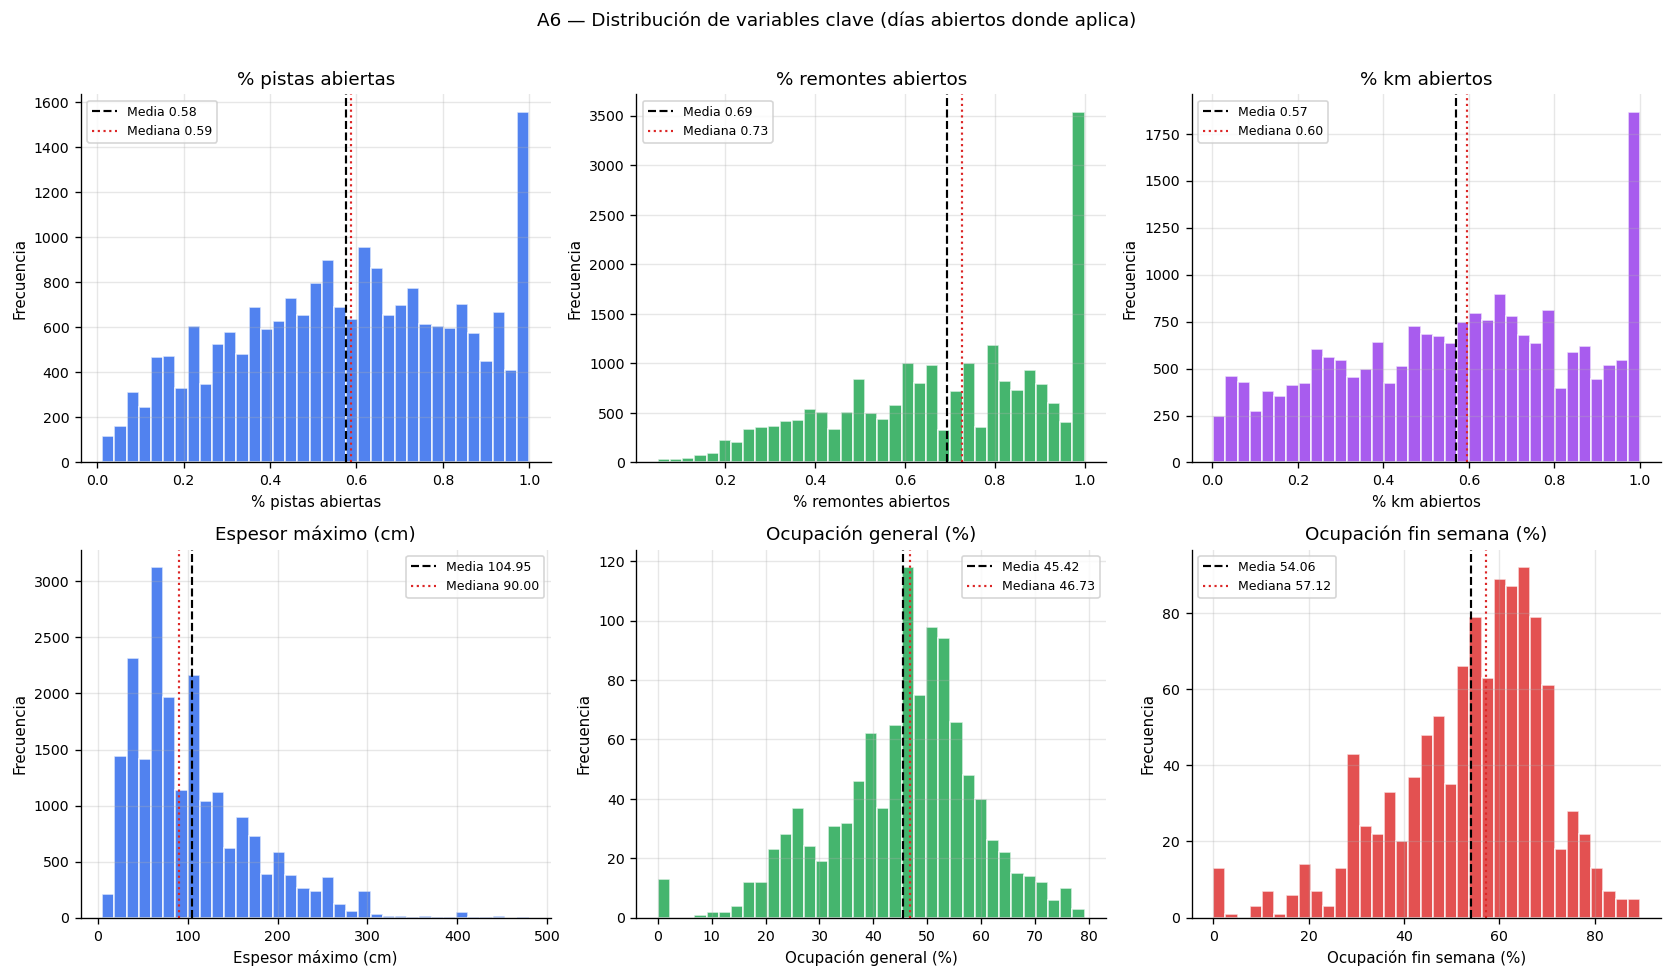

  ✓ A6_distribuciones_variables_clave.png


In [8]:
# A6 — Distribuciones de variables clave ──────────────────────────────────────
# En días abiertos para los ratios operativos; sin filtro para ocupación
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

vars_config = [
    (abiertos, 'pct_pistas_abiertas',   '% pistas abiertas',  C1),
    (abiertos, 'pct_remontes_abiertos', '% remontes abiertos',C2),
    (abiertos, 'pct_km_abiertos',       '% km abiertos',      C4),
    (abiertos, 'espesor_maximo',        'Espesor máximo (cm)', C1),
    (mm_w[mm_w['ocupacion_general_pct'].notna()], 'ocupacion_general_pct', 'Ocupación general (%)', C2),
    (mm_w[mm_w['ocupacion_finde_pct'].notna()],   'ocupacion_finde_pct',   'Ocupación fin semana (%)', C3),
]
for ax, (df, col, label, color) in zip(axes, vars_config):
    datos = df[col].dropna()
    ax.hist(datos, bins=35, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(datos.mean(),   color='black',  linestyle='--', linewidth=1.3, label=f'Media {datos.mean():.2f}')
    ax.axvline(datos.median(), color=C3, linestyle=':', linewidth=1.3, label=f'Mediana {datos.median():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.set_title(label)
    ax.legend(fontsize=7.5)

plt.suptitle('A6 — Distribución de variables clave (días abiertos donde aplica)', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'A6_distribuciones_variables_clave')

---
## BLOQUE B — EDA `master_diario`

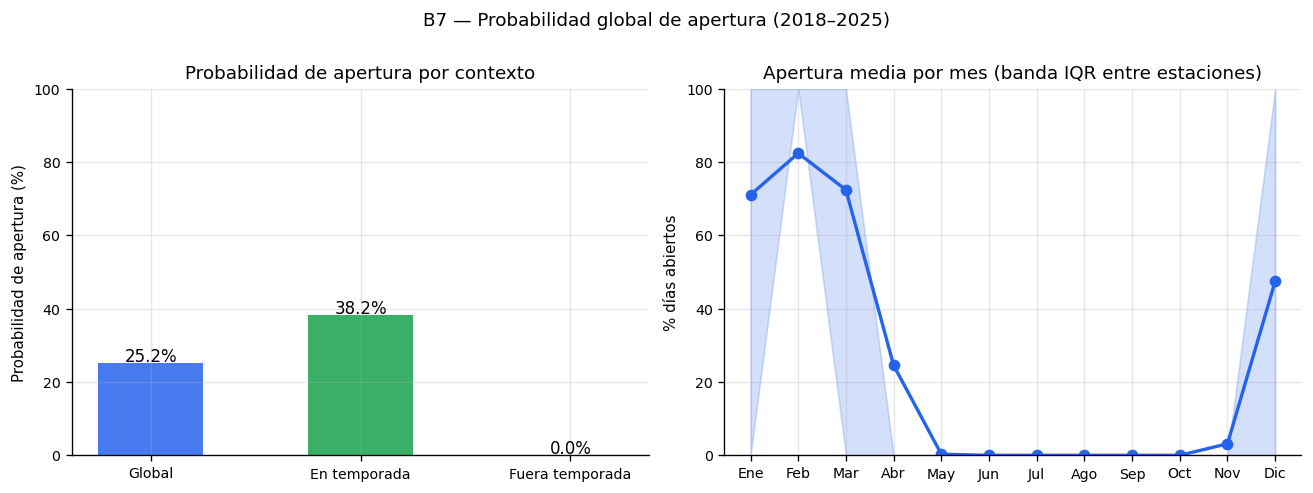

  ✓ B07_probabilidad_apertura.png


In [9]:
# B7 — Probabilidad global de apertura ────────────────────────────────────────
# Calcula: prob. de que una estación esté abierta dado que es temporada de esquí
p_global = md18['estado_abierta'].mean()
p_temp   = md18[md18['es_temporada_esqui']==True]['estado_abierta'].mean()
p_fueraT = md18[md18['es_temporada_esqui']==False]['estado_abierta'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cats = ['Global', 'En temporada', 'Fuera temporada']
vals = [p_global*100, p_temp*100, p_fueraT*100]
colores_b7 = [C1, C2, CGRIS]
bars = axes[0].bar(cats, vals, color=colores_b7, alpha=0.85, width=0.5)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
axes[0].set_ylabel('Probabilidad de apertura (%)')
axes[0].set_title('Probabilidad de apertura por contexto')
axes[0].set_ylim(0, 100)

# Evolución mensual de apertura: todo el histórico
apt_anio_mes = md18.groupby(['anio','mes'])['estado_abierta'].mean() * 100
apt_mes_media = md18.groupby('mes')['estado_abierta'].mean() * 100
# Área de dispersión
apt_mes_q25 = md18.groupby('mes')['estado_abierta'].apply(lambda x: np.percentile(x*100, 25))
apt_mes_q75 = md18.groupby('mes')['estado_abierta'].apply(lambda x: np.percentile(x*100, 75))
axes[1].fill_between(apt_mes_media.index, apt_mes_q25, apt_mes_q75, alpha=0.2, color=C1)
axes[1].plot(apt_mes_media.index, apt_mes_media.values, 'o-', color=C1, linewidth=2)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(MESES)
axes[1].set_ylabel('% días abiertos')
axes[1].set_title('Apertura media por mes (banda IQR entre estaciones)')
axes[1].set_ylim(0, 100)

plt.suptitle('B7 — Probabilidad global de apertura (2018–2025)', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'B07_probabilidad_apertura')

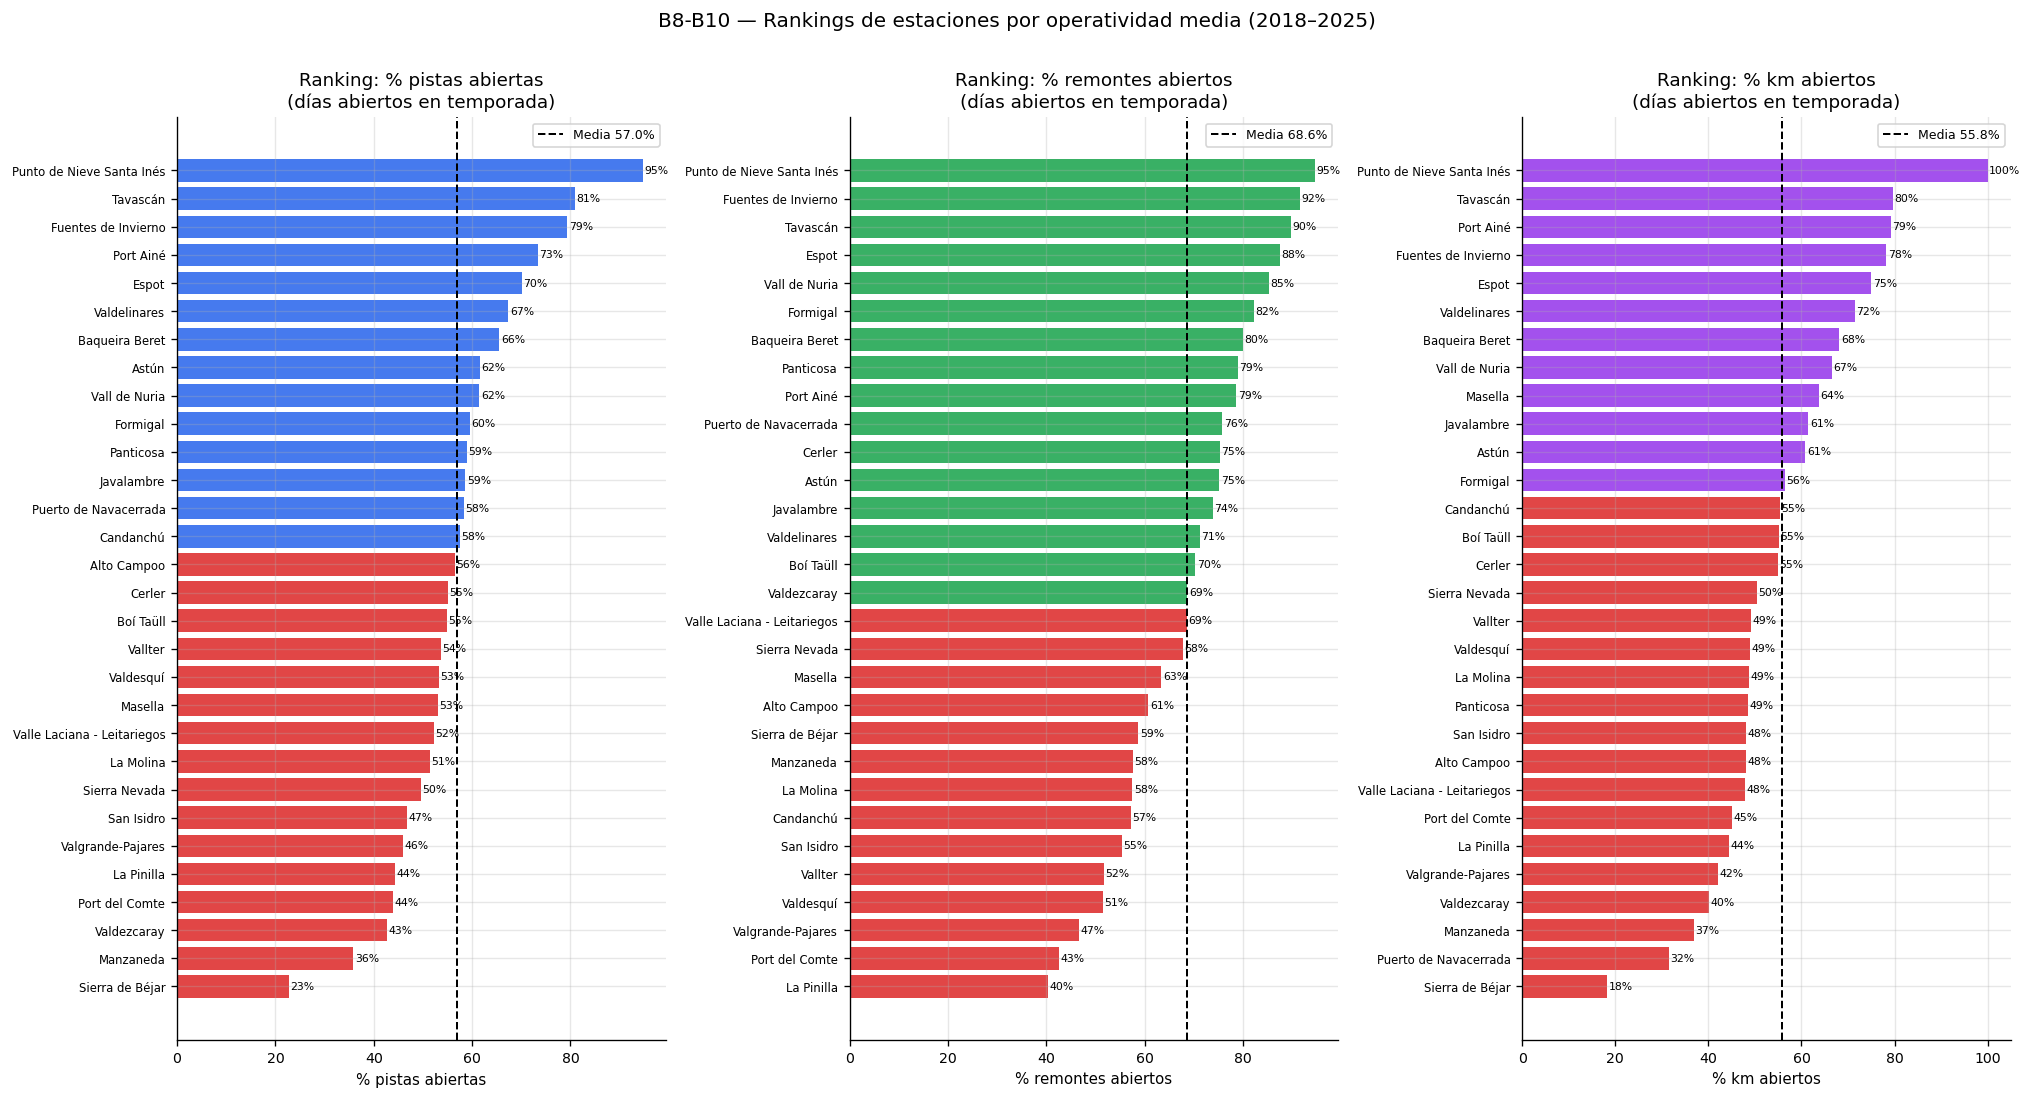

  ✓ B08_B10_rankings_operatividad.png


In [10]:
# B8-B10 — Rankings de estaciones por ratio medio de pistas, remontes y km ────
# Solo en días abiertos dentro de temporada (2018-2025)
en_temp = md18[(md18['es_temporada_esqui']==True) & (md18['estado_abierta']==1)]

rank_pistas   = en_temp.groupby('estacion')['pct_pistas_abiertas'].mean().sort_values()
rank_remontes = en_temp.groupby('estacion')['pct_remontes_abiertos'].mean().sort_values()
rank_km       = en_temp.groupby('estacion')['pct_km_abiertos'].mean().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(17, 9))

for ax, rank, label, color in [
    (axes[0], rank_pistas,   '% pistas abiertas',  C1),
    (axes[1], rank_remontes, '% remontes abiertos',C2),
    (axes[2], rank_km,       '% km abiertos',      C4),
]:
    colores_r = [C3 if v < rank.mean() else color for v in rank.values]
    ax.barh(rank.index, rank.values * 100, color=colores_r, alpha=0.85)
    ax.axvline(rank.mean() * 100, color='black', linestyle='--', linewidth=1.2,
               label=f'Media {rank.mean()*100:.1f}%')
    for i, v in enumerate(rank.values):
        ax.text(v * 100 + 0.3, i, f'{v*100:.0f}%', va='center', fontsize=6.5)
    ax.set_xlabel(label)
    ax.set_title(f'Ranking: {label}\n(días abiertos en temporada)')
    ax.legend(fontsize=7.5)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('B8-B10 — Rankings de estaciones por operatividad media (2018–2025)', fontsize=12, y=1.01)
plt.tight_layout()
save(fig, 'B08_B10_rankings_operatividad')

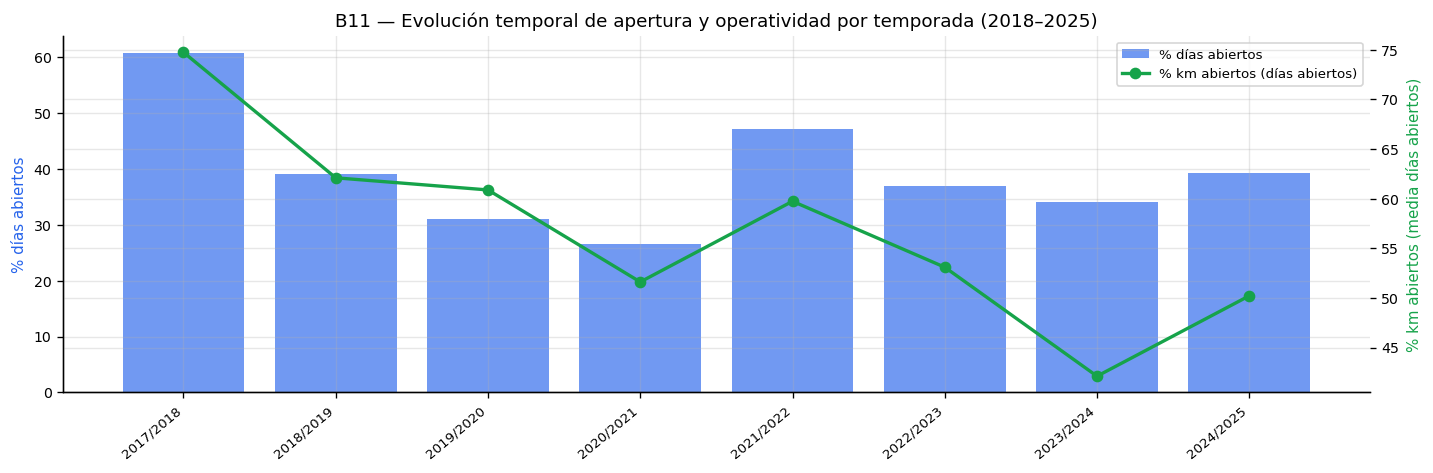

  ✓ B11_evolucion_apertura_temporada.png


In [11]:
# B11 — Evolución temporal de apertura global (por temporada) ─────────────────
apt_temp = md18[md18['es_temporada_esqui']==True].groupby('temporada_esqui').agg(
    apertura_media = ('estado_abierta','mean'),
    km_med         = ('pct_km_abiertos','mean'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
x = range(len(apt_temp))
bars = ax1.bar(x, apt_temp['apertura_media']*100, color=C1, alpha=0.65, label='% días abiertos')
ax2.plot(x, apt_temp['km_med']*100, 'o-', color=C2, linewidth=2, label='% km abiertos (días abiertos)')
ax1.set_xticks(x)
ax1.set_xticklabels(apt_temp['temporada_esqui'], rotation=40, ha='right', fontsize=8)
ax1.set_ylabel('% días abiertos', color=C1)
ax2.set_ylabel('% km abiertos (media días abiertos)', color=C2)
ax1.set_title('B11 — Evolución temporal de apertura y operatividad por temporada (2018–2025)')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, fontsize=8)
plt.tight_layout()
save(fig, 'B11_evolucion_apertura_temporada')

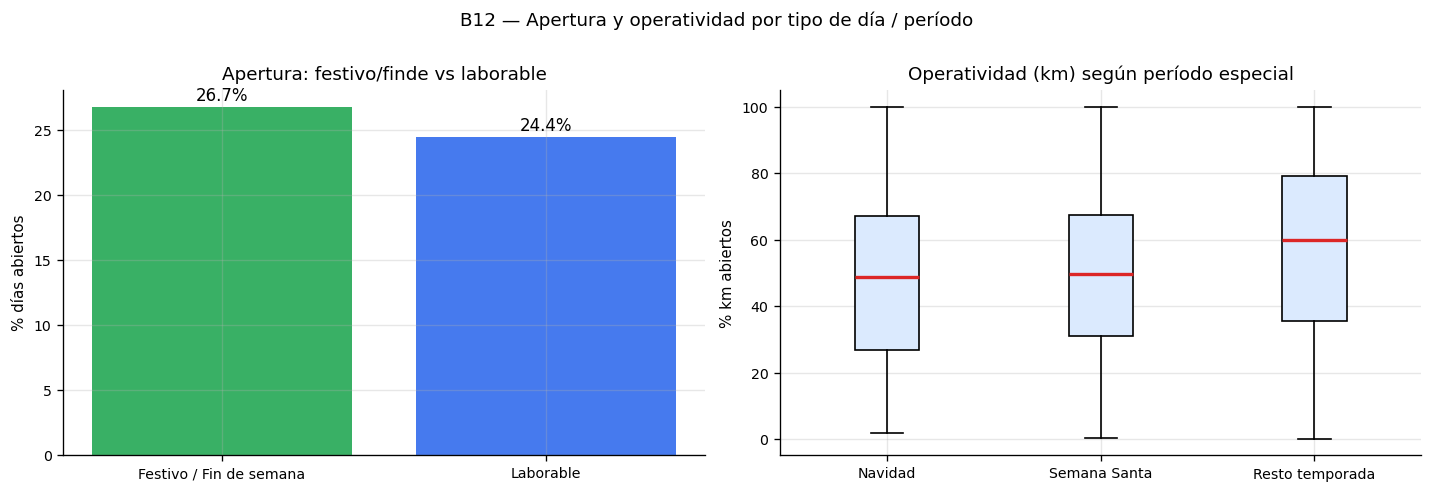

  ✓ B12_apertura_tipo_dia.png


In [12]:
# B12 — Apertura por tipo de día (finde, festivo, laboral) ────────────────────
md18_c = md18.copy()
conds = [
    (md18_c['es_finde']==1) | (md18_c['es_festivo']==1),
    (md18_c['es_finde']==0) & (md18_c['es_festivo']==0),
]
md18_c['tipo_dia'] = np.select(conds, ['Festivo / Fin de semana','Laborable'], default='Laborable')

# También: Navidad, Semana Santa, resto
md18_c['periodo'] = 'Resto temporada'
md18_c.loc[md18_c['semana_navidad']==1, 'periodo'] = 'Navidad'
md18_c.loc[md18_c['semana_santa']==1,   'periodo'] = 'Semana Santa'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Apertura por tipo de día
apt_tipo = md18_c.groupby('tipo_dia')['estado_abierta'].mean() * 100
bars = axes[0].bar(apt_tipo.index, apt_tipo.values, color=[C2, C1], alpha=0.85)
for bar, v in zip(bars, apt_tipo.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=10)
axes[0].set_ylabel('% días abiertos')
axes[0].set_title('Apertura: festivo/finde vs laborable')

# % km abiertos en días abiertos por período
grupos_per = {p: md18_c[(md18_c['periodo']==p)&(md18_c['estado_abierta']==1)]['pct_km_abiertos'].dropna()
              for p in ['Navidad','Semana Santa','Resto temporada']}
axes[1].boxplot(
    [grupos_per[k] * 100 for k in grupos_per],
    labels=list(grupos_per.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='#DBEAFE'),
    medianprops=dict(color=C3, linewidth=2),
    flierprops=dict(marker='.', markersize=2.5, alpha=0.3)
)
axes[1].set_ylabel('% km abiertos')
axes[1].set_title('Operatividad (km) según período especial')

plt.suptitle('B12 — Apertura y operatividad por tipo de día / período', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'B12_apertura_tipo_dia')

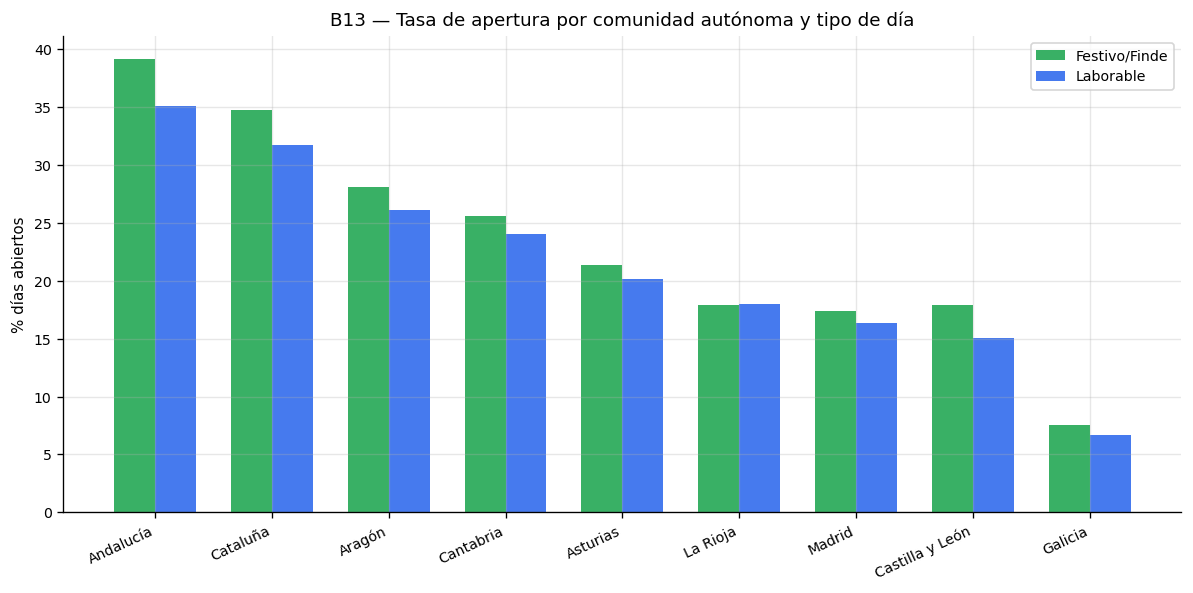

  ✓ B13_apertura_comunidad_tipo_dia.png


In [13]:
# B13 — Apertura por tipo de día y comunidad autónoma ────────────────────────
apt_com = md18_c.groupby(['comunidad','tipo_dia'])['estado_abierta'].mean().unstack() * 100
apt_com = apt_com.sort_values('Laborable', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(apt_com))
w = 0.35
ax.bar(x - w/2, apt_com.get('Festivo / Fin de semana', 0), w, label='Festivo/Finde', color=C2, alpha=0.85)
ax.bar(x + w/2, apt_com.get('Laborable', 0),               w, label='Laborable',    color=C1, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(apt_com.index, rotation=25, ha='right')
ax.set_ylabel('% días abiertos')
ax.set_title('B13 — Tasa de apertura por comunidad autónoma y tipo de día')
ax.legend()
plt.tight_layout()
save(fig, 'B13_apertura_comunidad_tipo_dia')

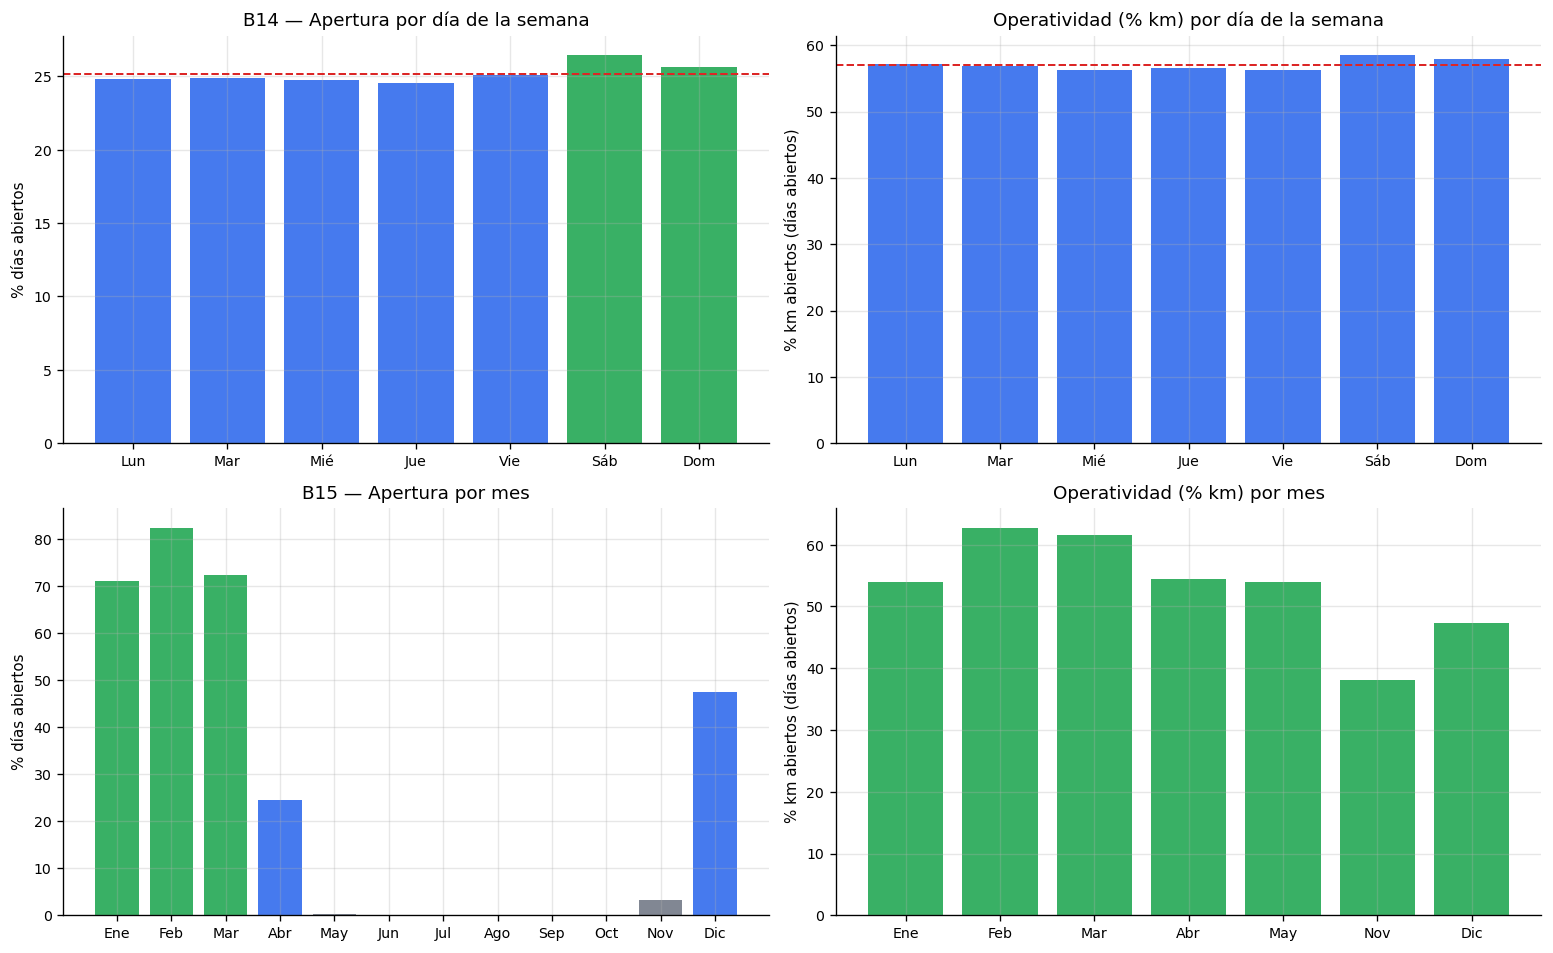

  ✓ B14_B15_apertura_dia_mes.png


In [14]:
# B14 — Apertura por día de la semana
# B15 — Apertura por mes
apt_dia = md18.groupby('dia_semana')['estado_abierta'].mean() * 100
apt_mes = md18.groupby('mes')['estado_abierta'].mean() * 100
op_dia  = abiertos.groupby('dia_semana')['pct_km_abiertos'].mean() * 100
op_mes  = abiertos.groupby('mes')['pct_km_abiertos'].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# B14a: apertura por día
colores_d = [C2 if v >= apt_dia.mean() else C1 for v in apt_dia.values]
axes[0,0].bar([DIAS[d] for d in apt_dia.index], apt_dia.values, color=colores_d, alpha=0.85)
axes[0,0].axhline(apt_dia.mean(), color=C3, linestyle='--', linewidth=1.2)
axes[0,0].set_ylabel('% días abiertos')
axes[0,0].set_title('B14 — Apertura por día de la semana')

# B14b: operatividad km por día
axes[0,1].bar([DIAS[d] for d in op_dia.index], op_dia.values, color=C1, alpha=0.85)
axes[0,1].axhline(op_dia.mean(), color=C3, linestyle='--', linewidth=1.2)
axes[0,1].set_ylabel('% km abiertos (días abiertos)')
axes[0,1].set_title('Operatividad (% km) por día de la semana')

# B15a: apertura por mes
colores_m = [C2 if v >= 50 else C1 if v >= 20 else CGRIS for v in apt_mes.values]
axes[1,0].bar(MESES, apt_mes.values, color=colores_m, alpha=0.85)
axes[1,0].set_ylabel('% días abiertos')
axes[1,0].set_title('B15 — Apertura por mes')

# B15b: operatividad km por mes
axes[1,1].bar([MESES[m-1] for m in op_mes.index], op_mes.values, color=C2, alpha=0.85)
axes[1,1].set_ylabel('% km abiertos (días abiertos)')
axes[1,1].set_title('Operatividad (% km) por mes')

plt.tight_layout()
save(fig, 'B14_B15_apertura_dia_mes')

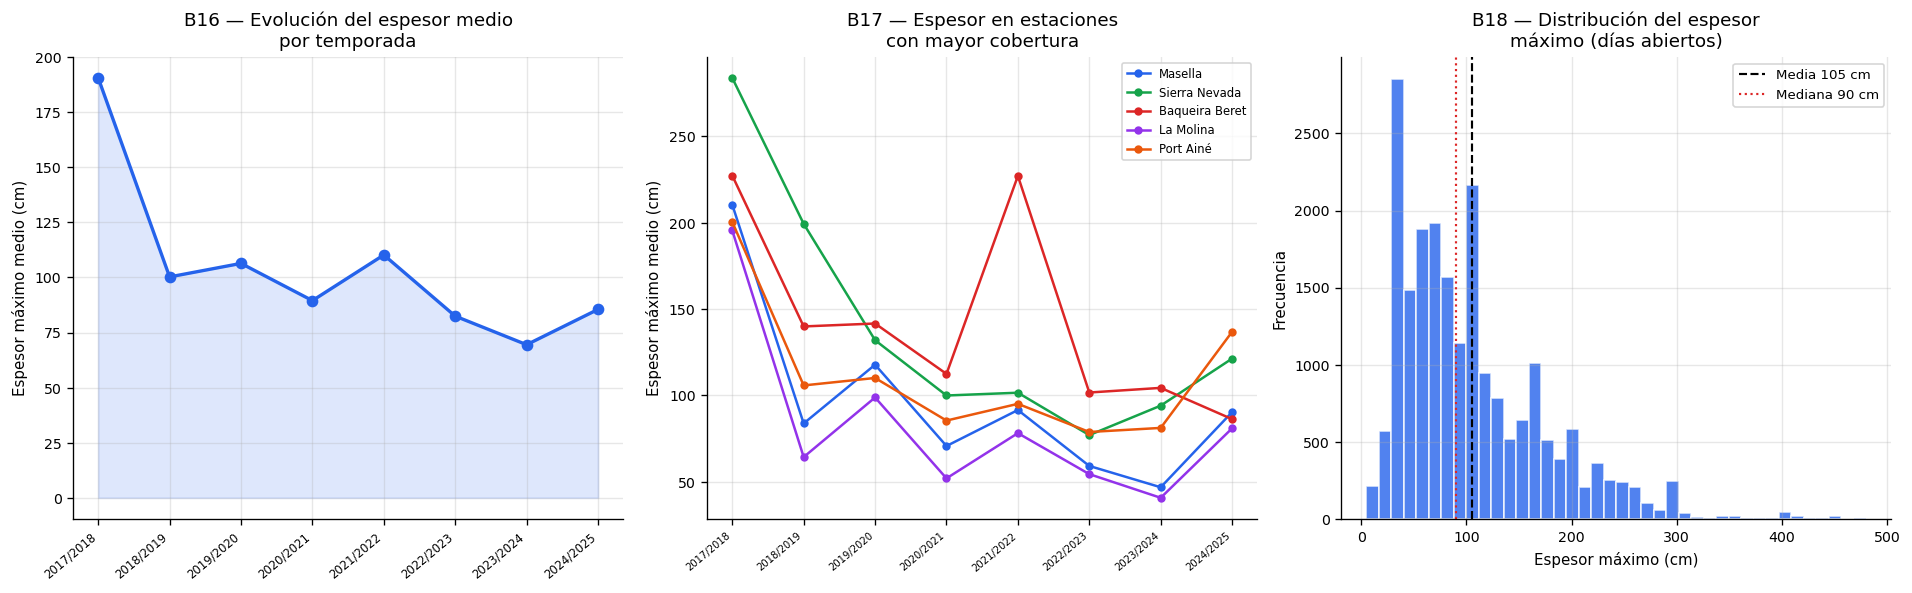

  ✓ B16_B18_espesor_nieve.png


In [15]:
# B16 — Evolución temporal del espesor medio de nieve (temporadas)
# B17 — Evolución del espesor en estaciones seleccionadas
# B18 — Distribución del espesor medio

esp = abiertos.dropna(subset=['espesor_maximo']).copy()
esp_temp = esp.groupby('temporada_esqui')['espesor_maximo'].mean()

# Selección de estaciones con más datos de espesor para B17
cobertura_esp = esp.groupby('estacion')['espesor_maximo'].count().sort_values(ascending=False)
top5_esp = cobertura_esp.head(5).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# B16
axes[0].plot(range(len(esp_temp)), esp_temp.values, 'o-', color=C1, linewidth=2)
axes[0].fill_between(range(len(esp_temp)), esp_temp.values, alpha=0.15, color=C1)
axes[0].set_xticks(range(len(esp_temp)))
axes[0].set_xticklabels(esp_temp.index, rotation=40, ha='right', fontsize=7)
axes[0].set_ylabel('Espesor máximo medio (cm)')
axes[0].set_title('B16 — Evolución del espesor medio\npor temporada')

# B17
colors_esp = [C1, C2, C3, C4, '#EA580C']
for est, col in zip(top5_esp, colors_esp):
    serie = esp[esp['estacion']==est].groupby('temporada_esqui')['espesor_maximo'].mean()
    axes[1].plot(range(len(serie)), serie.values, 'o-', color=col, linewidth=1.5,
                 label=est, markersize=4)
axes[1].set_xticks(range(len(esp_temp)))
axes[1].set_xticklabels(esp_temp.index, rotation=40, ha='right', fontsize=6)
axes[1].set_ylabel('Espesor máximo medio (cm)')
axes[1].set_title('B17 — Espesor en estaciones\ncon mayor cobertura')
axes[1].legend(fontsize=7)

# B18
axes[2].hist(esp['espesor_maximo'], bins=40, color=C1, alpha=0.8, edgecolor='white')
axes[2].axvline(esp['espesor_maximo'].mean(),   color='black', linestyle='--', linewidth=1.3,
                label=f'Media {esp["espesor_maximo"].mean():.0f} cm')
axes[2].axvline(esp['espesor_maximo'].median(), color=C3,     linestyle=':',  linewidth=1.3,
                label=f'Mediana {esp["espesor_maximo"].median():.0f} cm')
axes[2].set_xlabel('Espesor máximo (cm)')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('B18 — Distribución del espesor\nmáximo (días abiertos)')
axes[2].legend(fontsize=8)

plt.tight_layout()
save(fig, 'B16_B18_espesor_nieve')

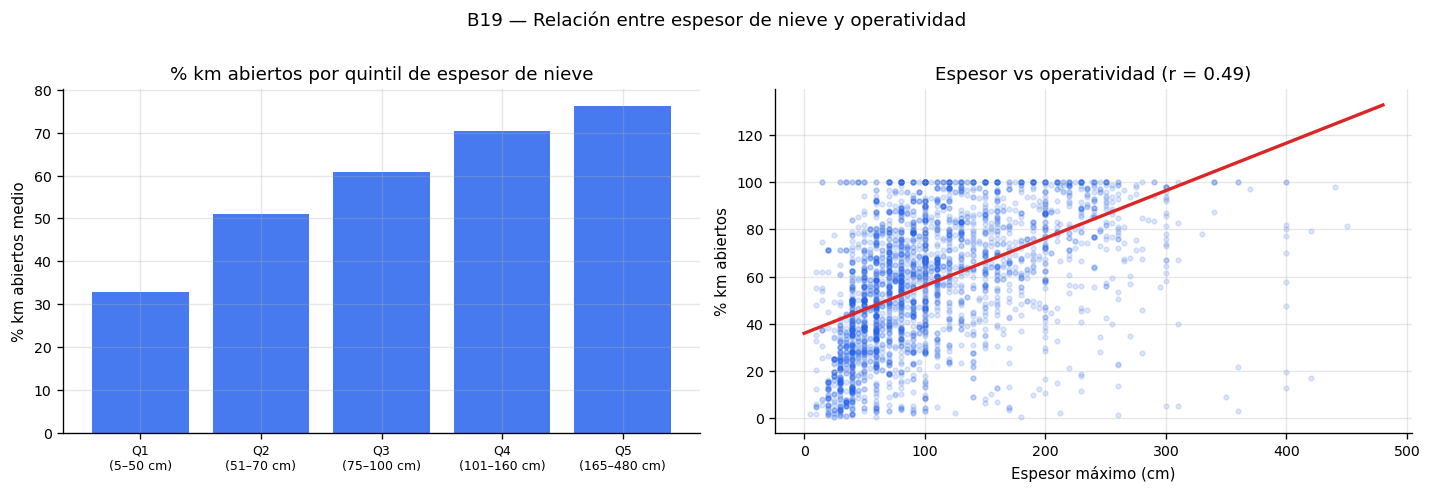

  ✓ B19_espesor_vs_operatividad.png


In [16]:
# B19 — Relación entre espesor de nieve y apertura (ratio km) ─────────────────
# Solo días abiertos con datos de espesor
esp_op = abiertos.dropna(subset=['espesor_maximo','pct_km_abiertos']).copy()

# Binear espesor en cuartiles para visualización clara
esp_op['bin_esp'] = pd.qcut(esp_op['espesor_maximo'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
apt_por_esp = esp_op.groupby('bin_esp')['pct_km_abiertos'].mean() * 100
rangos = esp_op.groupby('bin_esp')['espesor_maximo'].apply(lambda x: f'{x.min():.0f}–{x.max():.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras: km operativo por quintil de espesor
axes[0].bar(range(5), apt_por_esp.values, color=C1, alpha=0.85)
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([f'{q}\n({r} cm)' for q, r in zip(['Q1','Q2','Q3','Q4','Q5'], rangos)],
                        fontsize=7.5)
axes[0].set_ylabel('% km abiertos medio')
axes[0].set_title('% km abiertos por quintil de espesor de nieve')

# Scatter (muestra)
sample = esp_op.sample(min(3000, len(esp_op)), random_state=42)
axes[1].scatter(sample['espesor_maximo'], sample['pct_km_abiertos']*100,
                alpha=0.15, s=8, color=C1)
m, b = np.polyfit(esp_op['espesor_maximo'], esp_op['pct_km_abiertos']*100, 1)
x_ = np.linspace(0, esp_op['espesor_maximo'].max(), 100)
axes[1].plot(x_, m*x_+b, color=C3, linewidth=2)
r = np.corrcoef(esp_op['espesor_maximo'], esp_op['pct_km_abiertos'])[0,1]
axes[1].set_xlabel('Espesor máximo (cm)')
axes[1].set_ylabel('% km abiertos')
axes[1].set_title(f'Espesor vs operatividad (r = {r:.2f})')

plt.suptitle('B19 — Relación entre espesor de nieve y operatividad', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'B19_espesor_vs_operatividad')

Estaciones con cobertura meteo: ['Astún' 'Candanchú' 'Cerler' 'Formigal' 'Panticosa' 'Sierra Nevada']


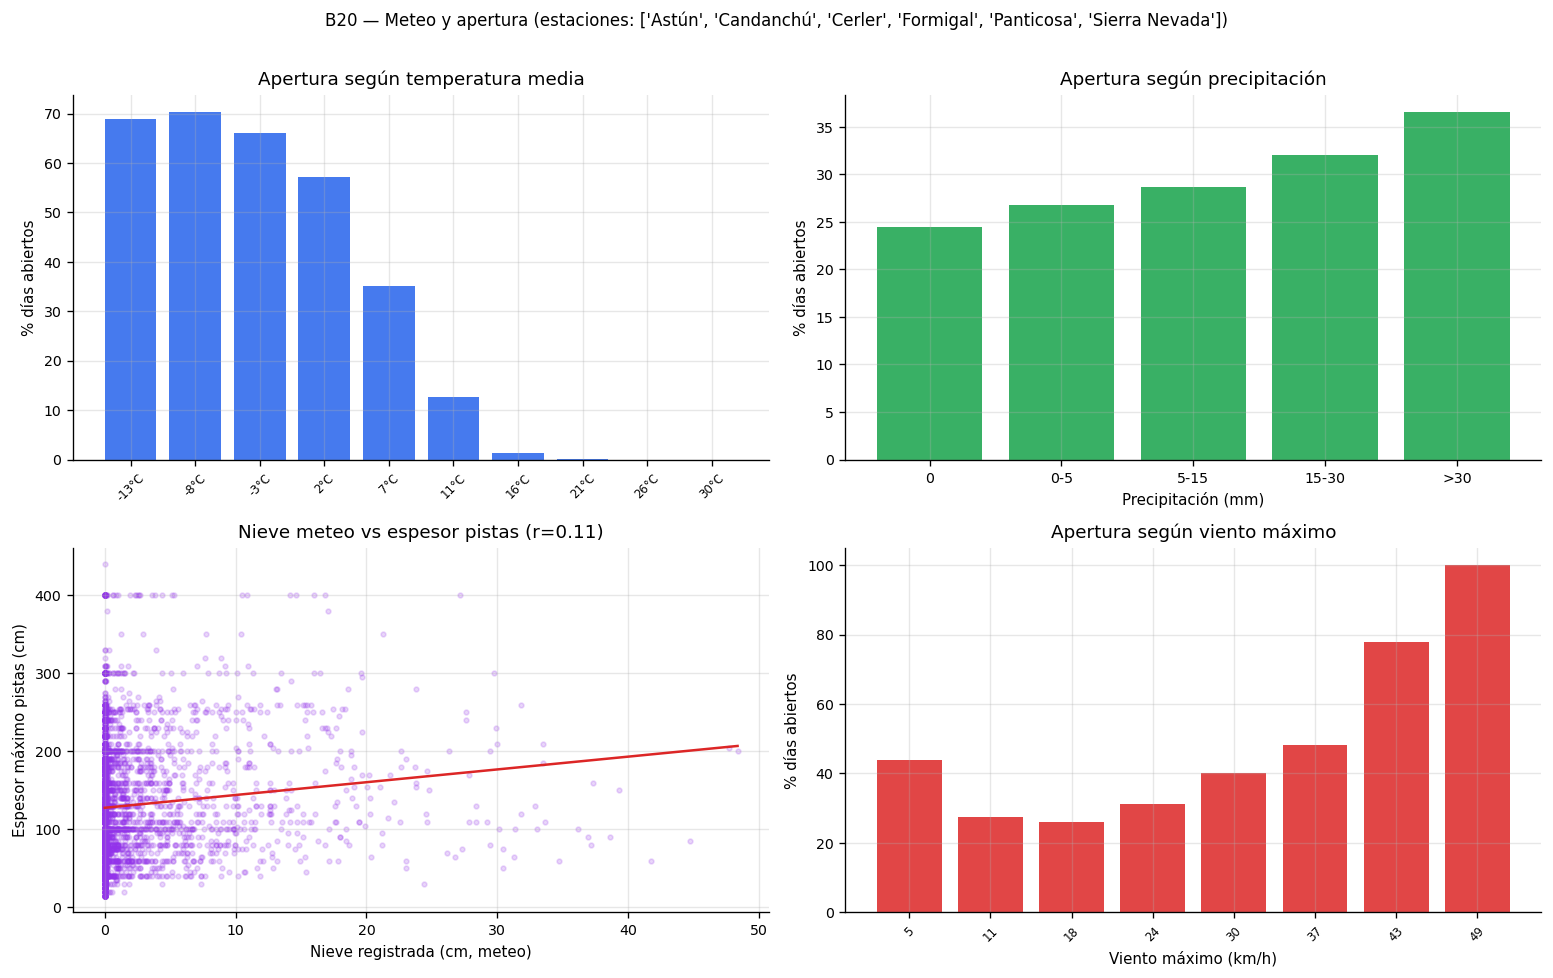

  ✓ B20_meteo_vs_apertura.png


In [17]:
# B20 — Análisis meteo y apertura (solo estaciones con cobertura) ──────────────
# meteo solo cubre 6 estaciones → análisis restringido a esas estaciones
md_meteo = md18.dropna(subset=['temp_media_c']).copy()
ests_meteo = md_meteo['estacion'].unique()
print(f'Estaciones con cobertura meteo: {ests_meteo}')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Temperatura media vs apertura
datos_t = md_meteo[['temp_media_c','estado_abierta']].dropna()
t_bins = pd.cut(datos_t['temp_media_c'], bins=10)
apt_t = datos_t.groupby(t_bins)['estado_abierta'].mean() * 100
axes[0,0].bar(range(len(apt_t)), apt_t.values, color=C1, alpha=0.85)
axes[0,0].set_xticks(range(len(apt_t)))
axes[0,0].set_xticklabels([f'{i.mid:.0f}°C' for i in apt_t.index], rotation=45, fontsize=7)
axes[0,0].set_ylabel('% días abiertos')
axes[0,0].set_title('Apertura según temperatura media')

# Precipitación vs apertura
datos_p = md_meteo[['precipitacion_mm','estado_abierta']].dropna()
p_bins = pd.cut(datos_p['precipitacion_mm'], bins=[0,1,5,15,30,999], labels=['0','0-5','5-15','15-30','>30'])
apt_p = datos_p.groupby(p_bins)['estado_abierta'].mean() * 100
axes[0,1].bar(apt_p.index, apt_p.values, color=C2, alpha=0.85)
axes[0,1].set_xlabel('Precipitación (mm)')
axes[0,1].set_ylabel('% días abiertos')
axes[0,1].set_title('Apertura según precipitación')

# Nieve meteo vs espesor infonieve
md_doble = md_meteo[md_meteo['estado_abierta']==1].dropna(subset=['nieve_cm','espesor_maximo'])
axes[1,0].scatter(md_doble['nieve_cm'], md_doble['espesor_maximo'],
                  alpha=0.2, s=8, color=C4)
if len(md_doble) > 10:
    m, b = np.polyfit(md_doble['nieve_cm'], md_doble['espesor_maximo'], 1)
    xr = np.linspace(0, md_doble['nieve_cm'].max(), 100)
    axes[1,0].plot(xr, m*xr+b, color=C3, linewidth=1.5)
    r2 = np.corrcoef(md_doble['nieve_cm'], md_doble['espesor_maximo'])[0,1]
    axes[1,0].set_title(f'Nieve meteo vs espesor pistas (r={r2:.2f})')
else:
    axes[1,0].set_title('Nieve meteo vs espesor (datos insuficientes)')
axes[1,0].set_xlabel('Nieve registrada (cm, meteo)')
axes[1,0].set_ylabel('Espesor máximo pistas (cm)')

# Viento vs apertura
datos_v = md_meteo[['viento_max_kmh','estado_abierta']].dropna()
v_bins = pd.cut(datos_v['viento_max_kmh'], bins=8)
apt_v = datos_v.groupby(v_bins)['estado_abierta'].mean() * 100
axes[1,1].bar(range(len(apt_v)), apt_v.values, color=C3, alpha=0.85)
axes[1,1].set_xticks(range(len(apt_v)))
axes[1,1].set_xticklabels([f'{i.mid:.0f}' for i in apt_v.index], rotation=45, fontsize=7)
axes[1,1].set_xlabel('Viento máximo (km/h)')
axes[1,1].set_ylabel('% días abiertos')
axes[1,1].set_title('Apertura según viento máximo')

plt.suptitle(f'B20 — Meteo y apertura (estaciones: {list(ests_meteo)})', fontsize=10, y=1.01)
plt.tight_layout()
save(fig, 'B20_meteo_vs_apertura')

---
## BLOQUE C — EDA `master_mensual`

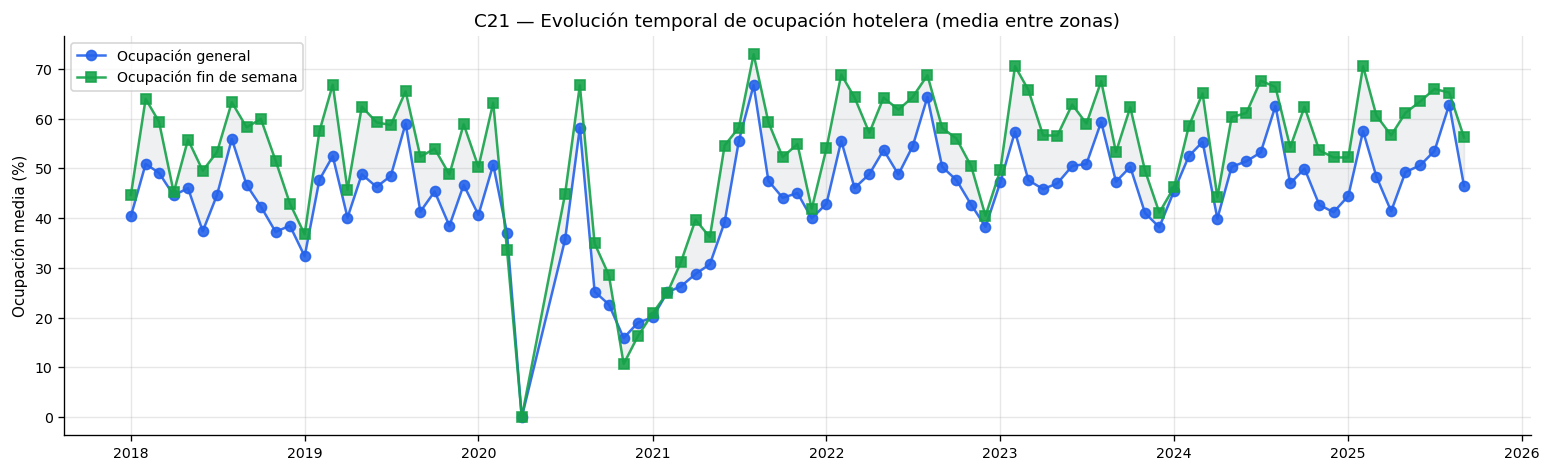

  ✓ C21_evolucion_ocupacion.png


In [19]:
# C21 — Evolución temporal de ocupación hotelera media mensual ────────────────
# C21 — Evolución temporal de ocupación hotelera media mensual
oc = mm_w[mm_w['ocupacion_general_pct'].notna()].copy()

oc['fecha_mes'] = pd.to_datetime(
    dict(year=oc['anio'], month=oc['mes'], day=1)
)

oc_evol = oc.groupby('fecha_mes')[['ocupacion_general_pct', 'ocupacion_finde_pct']].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(oc_evol.index, oc_evol['ocupacion_general_pct'], '-o', color=C1, linewidth=1.5,
        label='Ocupación general', alpha=0.9)
ax.plot(oc_evol.index, oc_evol['ocupacion_finde_pct'], '-s', color=C2, linewidth=1.5,
        label='Ocupación fin de semana', alpha=0.9)
ax.fill_between(oc_evol.index,
                oc_evol['ocupacion_general_pct'],
                oc_evol['ocupacion_finde_pct'],
                alpha=0.1, color=CGRIS)
ax.set_ylabel('Ocupación media (%)')
ax.set_title('C21 — Evolución temporal de ocupación hotelera (media entre zonas)')
ax.legend()
plt.tight_layout()
save(fig, 'C21_evolucion_ocupacion')

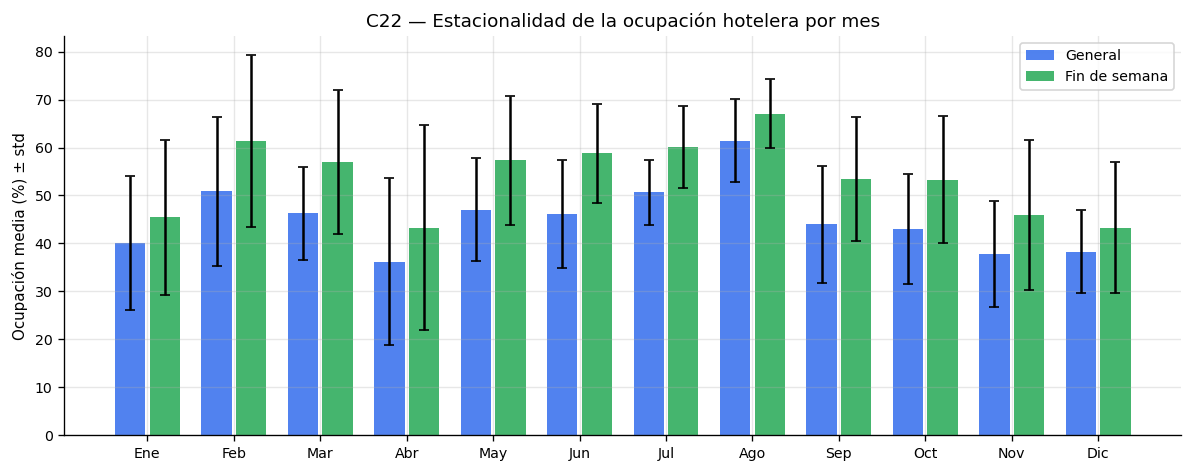

  ✓ C22_estacionalidad_ocupacion.png


In [20]:
# C22 — Estacionalidad de la ocupación por mes ────────────────────────────────
oc_mes = oc.groupby('mes')[['ocupacion_general_pct','ocupacion_finde_pct']].agg(['mean','std'])
oc_mes.columns = ['gen_mean','gen_std','finde_mean','finde_std']

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(12)
ax.bar(x - 0.2, oc_mes['gen_mean'],   0.35, yerr=oc_mes['gen_std'],   label='General',       color=C1, alpha=0.8, capsize=3)
ax.bar(x + 0.2, oc_mes['finde_mean'], 0.35, yerr=oc_mes['finde_std'], label='Fin de semana', color=C2, alpha=0.8, capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(MESES)
ax.set_ylabel('Ocupación media (%) ± std')
ax.set_title('C22 — Estacionalidad de la ocupación hotelera por mes')
ax.legend()
plt.tight_layout()
save(fig, 'C22_estacionalidad_ocupacion')

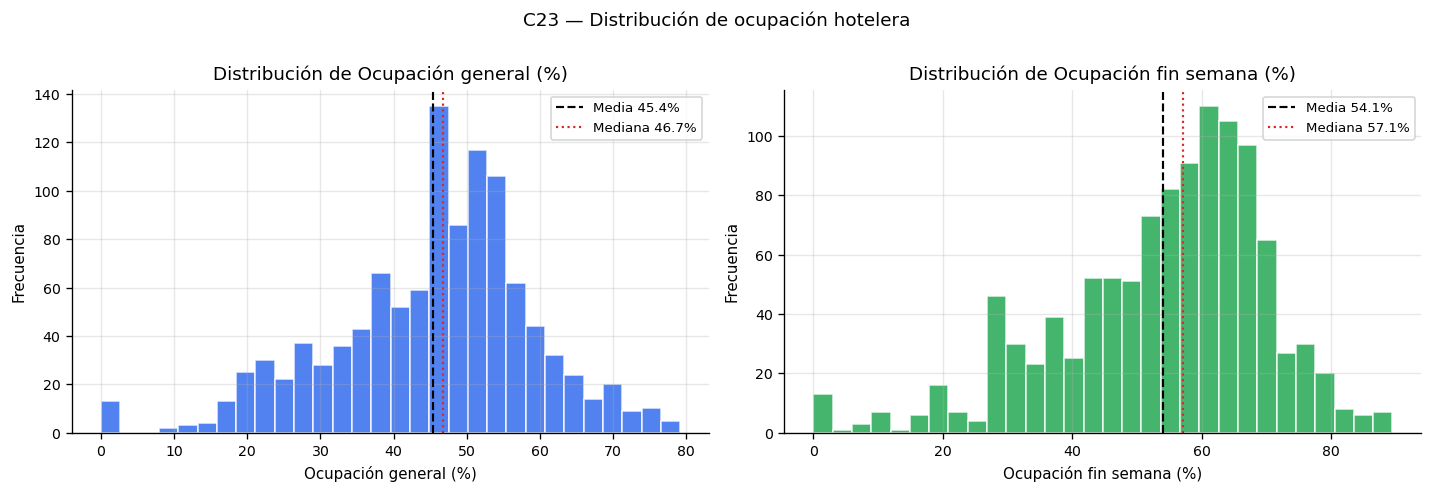

  ✓ C23_distribucion_ocupacion.png


In [21]:
# C23 — Distribución de ocupación hotelera ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label, color in [
    (axes[0], 'ocupacion_general_pct', 'Ocupación general (%)', C1),
    (axes[1], 'ocupacion_finde_pct',   'Ocupación fin semana (%)', C2),
]:
    datos = oc[col].dropna()
    ax.hist(datos, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(datos.mean(),   color='black', linestyle='--', linewidth=1.3,
               label=f'Media {datos.mean():.1f}%')
    ax.axvline(datos.median(), color=C3,     linestyle=':',  linewidth=1.3,
               label=f'Mediana {datos.median():.1f}%')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Distribución de {label}')
    ax.legend(fontsize=8)

plt.suptitle('C23 — Distribución de ocupación hotelera', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'C23_distribucion_ocupacion')

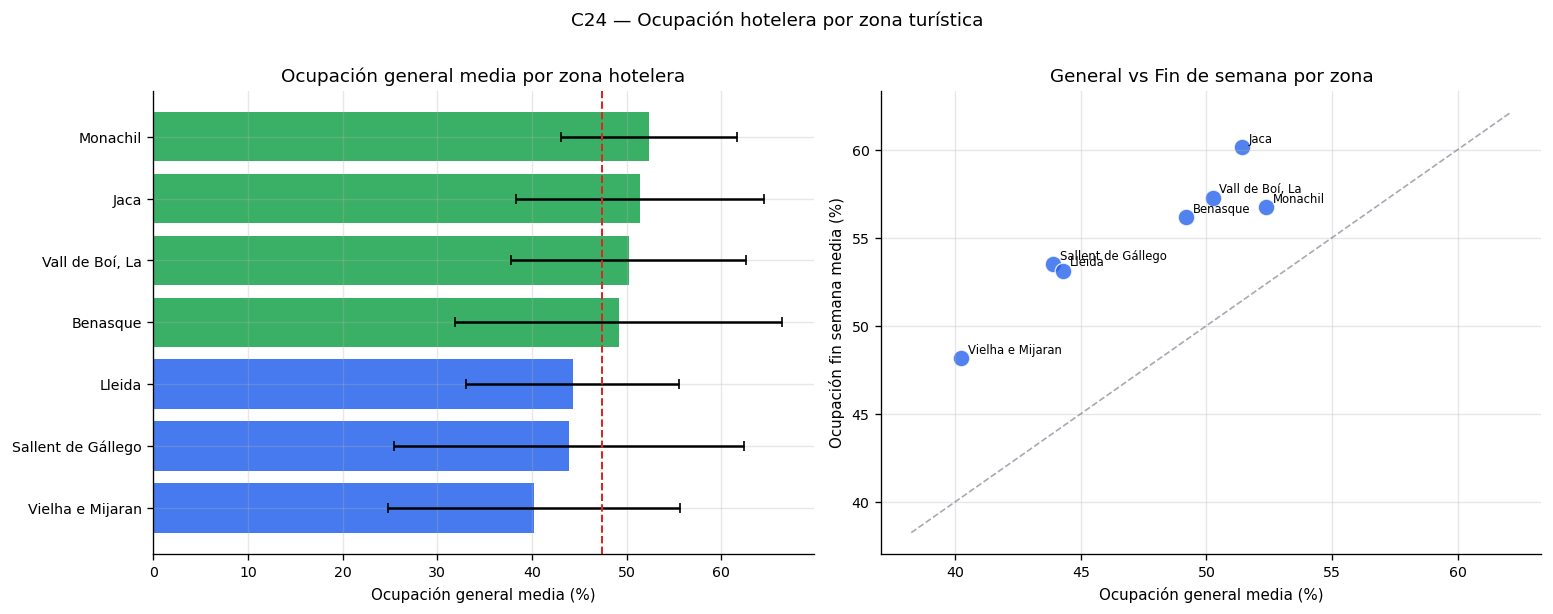

  ✓ C24_ocupacion_por_zona.png


In [22]:
# C24 — Comparación de ocupación por zonas hoteleras ─────────────────────────
oc_zona = oc.groupby('zona_hotelera').agg(
    gen_mean  = ('ocupacion_general_pct','mean'),
    finde_mean= ('ocupacion_finde_pct',  'mean'),
    gen_std   = ('ocupacion_general_pct','std'),
).sort_values('gen_mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_z = [C2 if v >= oc_zona['gen_mean'].mean() else C1 for v in oc_zona['gen_mean']]
axes[0].barh(oc_zona.index, oc_zona['gen_mean'], xerr=oc_zona['gen_std'],
             color=colores_z, alpha=0.85, capsize=3)
axes[0].axvline(oc_zona['gen_mean'].mean(), color=C3, linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Ocupación general media (%)')
axes[0].set_title('Ocupación general media por zona hotelera')

# General vs Finde
axes[1].scatter(oc_zona['gen_mean'], oc_zona['finde_mean'],
                s=100, color=C1, alpha=0.8, edgecolors='white', linewidth=0.8)
for zona in oc_zona.index:
    axes[1].annotate(zona, (oc_zona.loc[zona,'gen_mean'], oc_zona.loc[zona,'finde_mean']),
                     fontsize=7, xytext=(4,3), textcoords='offset points')
lims = [min(oc_zona['gen_mean'].min(), oc_zona['finde_mean'].min()) - 2,
        max(oc_zona['gen_mean'].max(), oc_zona['finde_mean'].max()) + 2]
axes[1].plot(lims, lims, color=CGRIS, linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_xlabel('Ocupación general media (%)')
axes[1].set_ylabel('Ocupación fin semana media (%)')
axes[1].set_title('General vs Fin de semana por zona')

plt.suptitle('C24 — Ocupación hotelera por zona turística', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'C24_ocupacion_por_zona')

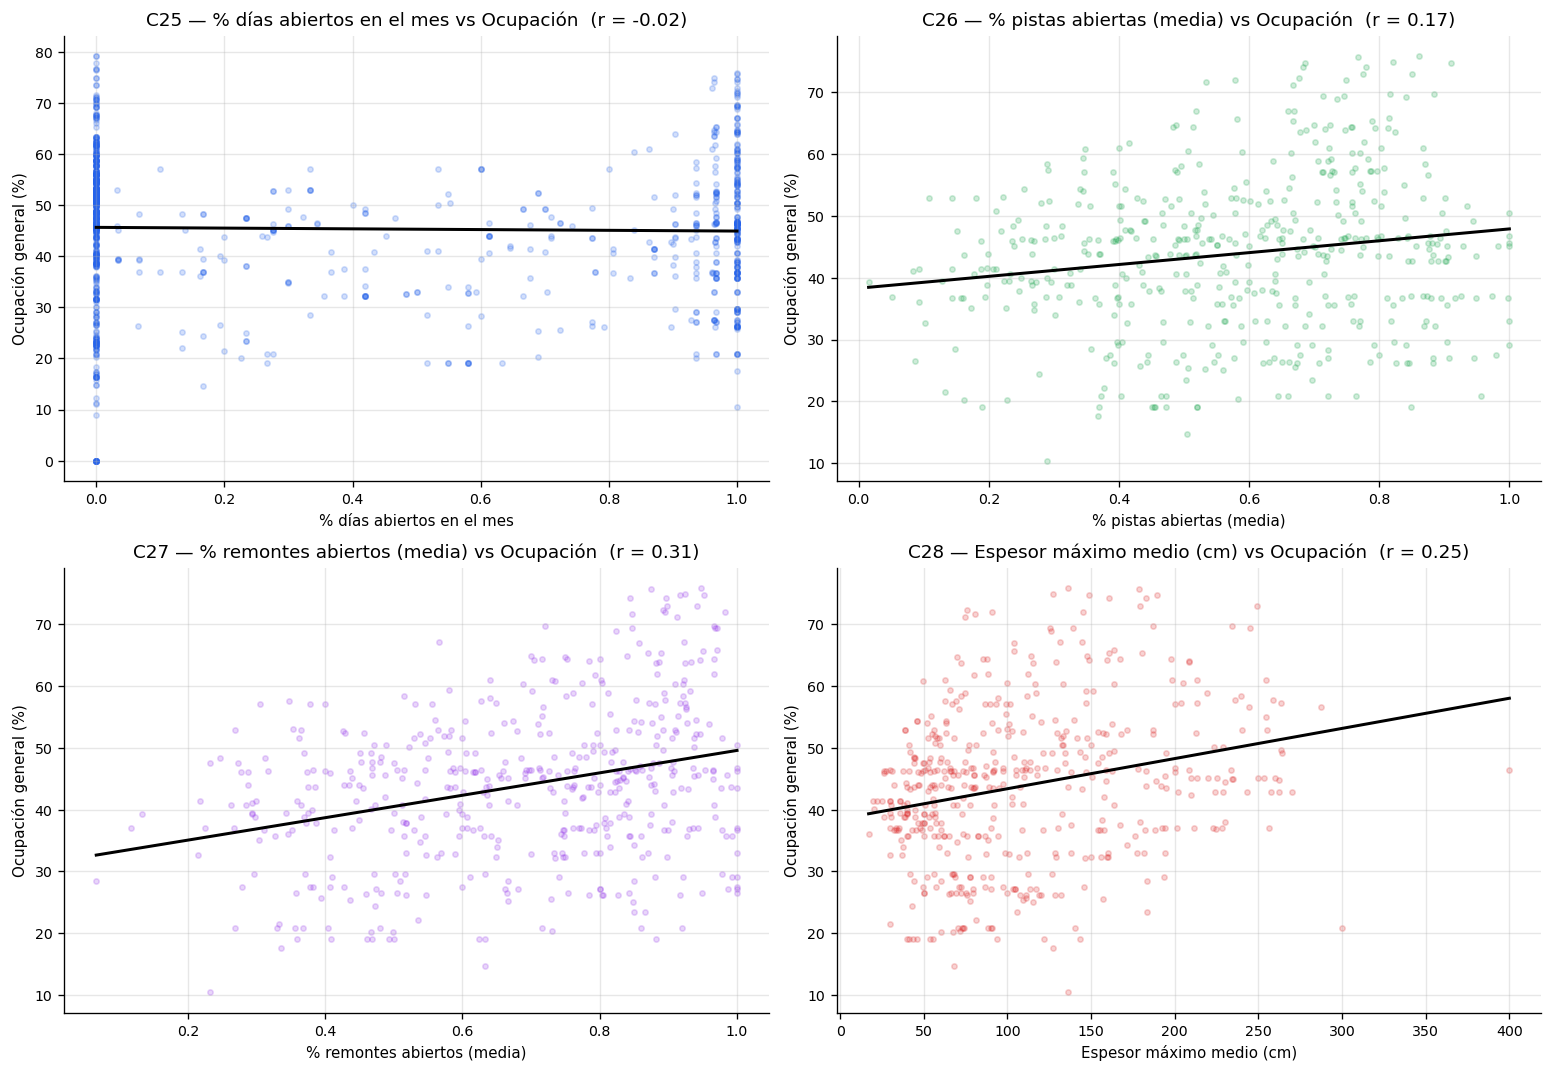

  ✓ C25_C28_operativas_vs_ocupacion.png


In [23]:
# C25-C28 — Relación variables operativas / espesor vs ocupación ──────────────
sub = mm_w[mm_w['ocupacion_general_pct'].notna()].copy()

pares = [
    ('pct_dias_abierta', '% días abiertos en el mes',   C1),
    ('pct_pistas_med',   '% pistas abiertas (media)',   C2),
    ('pct_remontes_med', '% remontes abiertos (media)', C4),
    ('espesor_max_med',  'Espesor máximo medio (cm)',   C3),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (xcol, xlabel, color), titulo_num in zip(axes, pares, ['C25','C26','C27','C28']):
    datos = sub[['ocupacion_general_pct', xcol]].dropna()
    if len(datos) < 10:
        ax.text(0.5, 0.5, 'Datos insuficientes', ha='center', transform=ax.transAxes)
        ax.set_title(f'{titulo_num} — Sin datos')
        continue
    ax.scatter(datos[xcol], datos['ocupacion_general_pct'],
               alpha=0.2, s=10, color=color)
    m, b = np.polyfit(datos[xcol], datos['ocupacion_general_pct'], 1)
    xr = np.linspace(datos[xcol].min(), datos[xcol].max(), 100)
    ax.plot(xr, m*xr+b, color='black', linewidth=1.8)
    r = np.corrcoef(datos[xcol], datos['ocupacion_general_pct'])[0,1]
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Ocupación general (%)')
    ax.set_title(f'{titulo_num} — {xlabel} vs Ocupación  (r = {r:.2f})')

plt.tight_layout()
save(fig, 'C25_C28_operativas_vs_ocupacion')

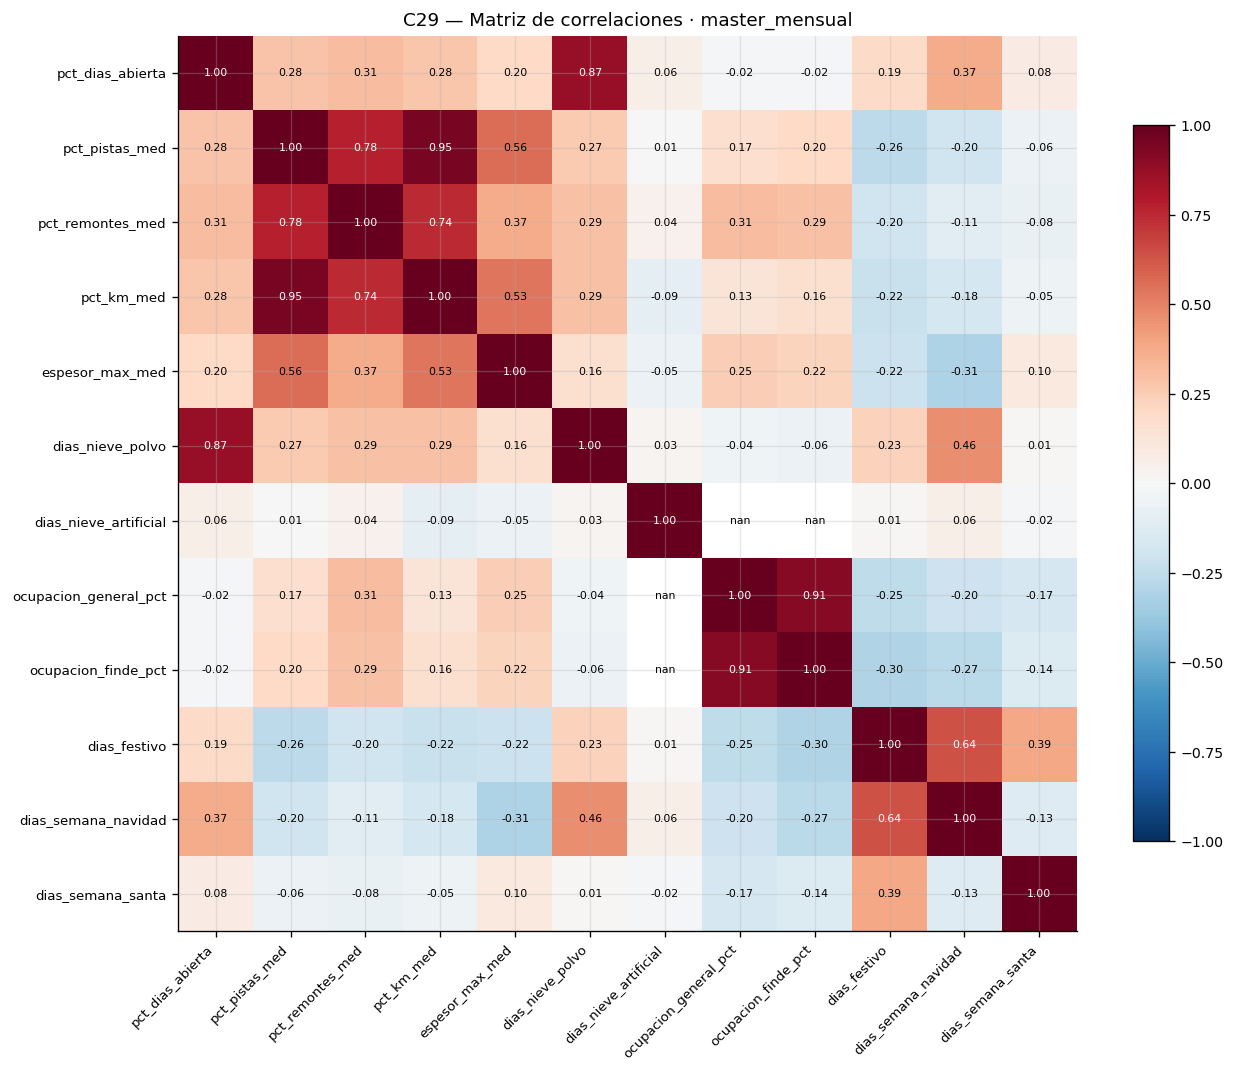

  ✓ C29_matriz_correlaciones.png


In [24]:
# C29 — Matriz de correlaciones variables clave del mensual ───────────────────
cols_corr = [
    'pct_dias_abierta','pct_pistas_med','pct_remontes_med','pct_km_med',
    'espesor_max_med','dias_nieve_polvo','dias_nieve_artificial',
    'ocupacion_general_pct','ocupacion_finde_pct',
    'dias_festivo','dias_semana_navidad','dias_semana_santa',
]
cols_corr = [c for c in cols_corr if c in mm_w.columns]
corr_mat = mm_w[cols_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(cols_corr)))
ax.set_yticks(range(len(cols_corr)))
ax.set_xticklabels(cols_corr, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cols_corr, fontsize=8)
for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        v = corr_mat.iloc[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5,
                color='white' if abs(v) > 0.6 else 'black')
ax.set_title('C29 — Matriz de correlaciones · master_mensual')
plt.tight_layout()
save(fig, 'C29_matriz_correlaciones')

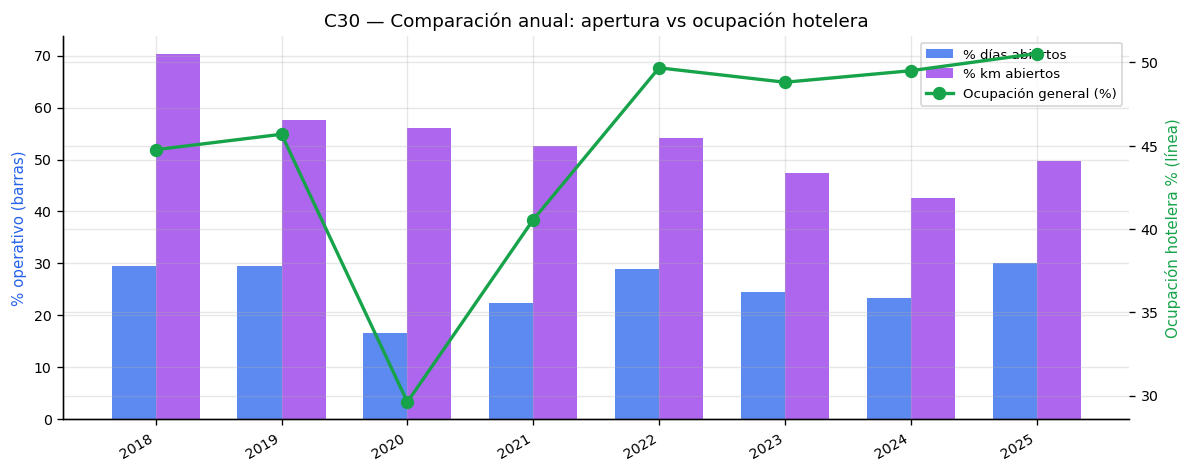

  ✓ C30_comparacion_anual_temporada.png


In [25]:
# C30 — Comparación por temporada: ocupación media y apertura media ────────────
mm18 = mm_w[mm_w['anio'] >= 2018].copy()
comp_temp = mm18.groupby('anio').agg(
    apertura_media  = ('pct_dias_abierta',     'mean'),
    km_medio        = ('pct_km_med',           'mean'),
    ocupacion_media = ('ocupacion_general_pct','mean'),
).reset_index().dropna()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
x = np.arange(len(comp_temp))
w = 0.35
ax1.bar(x - w/2, comp_temp['apertura_media']*100, w, color=C1, alpha=0.75, label='% días abiertos')
ax1.bar(x + w/2, comp_temp['km_medio']*100,       w, color=C4, alpha=0.75, label='% km abiertos')
ax2.plot(x, comp_temp['ocupacion_media'], 'o-', color=C2, linewidth=2, markersize=7,
         label='Ocupación general (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(comp_temp['anio'].astype(str), rotation=30, ha='right')
ax1.set_ylabel('% operativo (barras)', color=C1)
ax2.set_ylabel('Ocupación hotelera % (línea)', color=C2)
ax1.set_title('C30 — Comparación anual: apertura vs ocupación hotelera')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, fontsize=8)
plt.tight_layout()
save(fig, 'C30_comparacion_anual_temporada')

---
## BLOQUE D — Google Trends (dataset independiente)

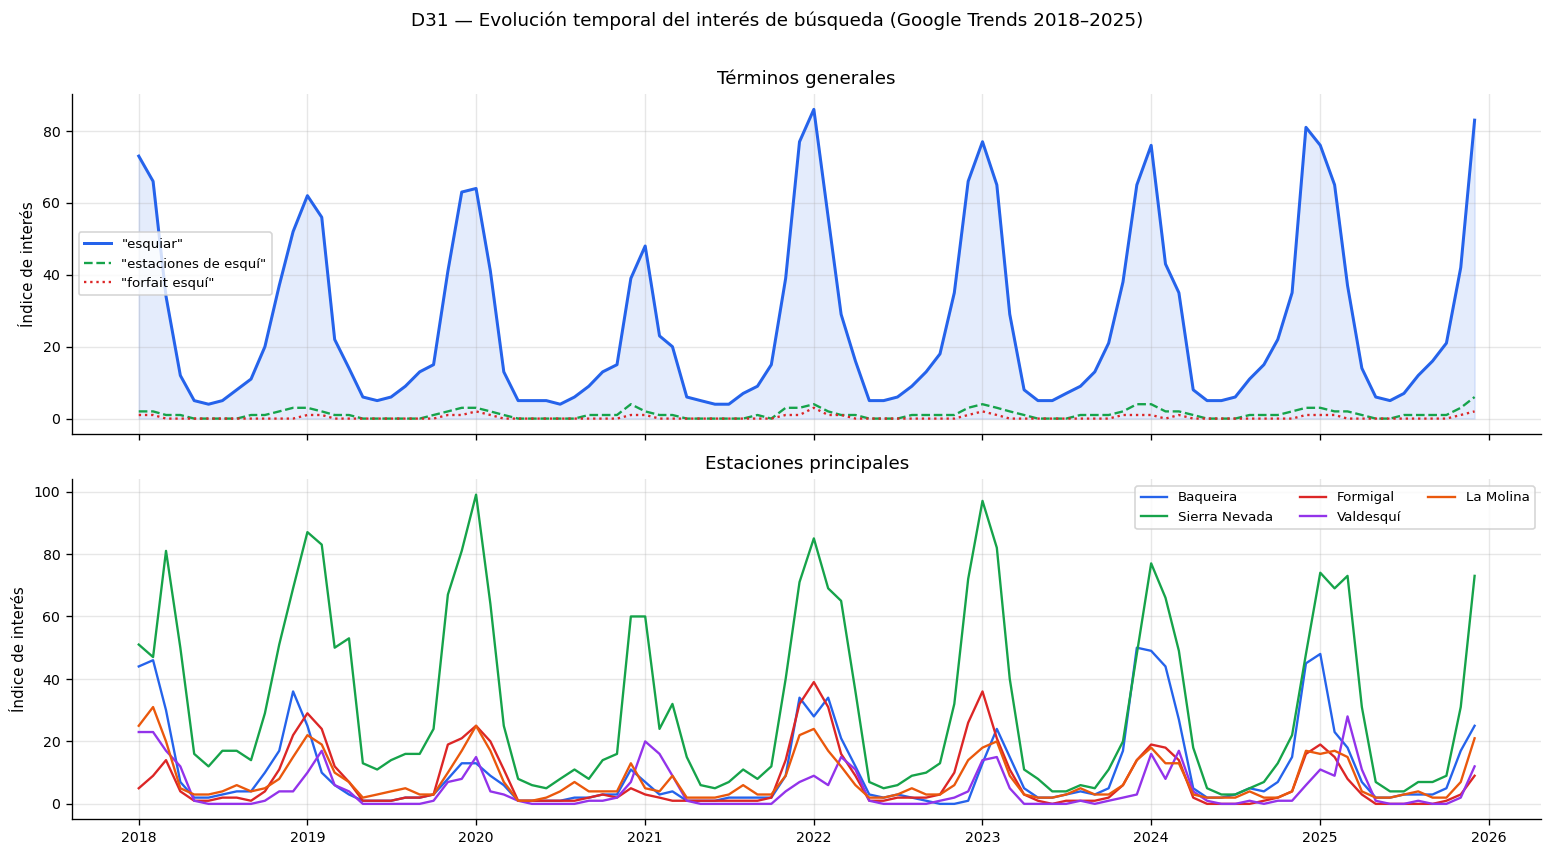

  ✓ D31_gtrends_evolucion.png


In [26]:
# D31 — Evolución temporal del interés en esquí ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Términos generales
axes[0].plot(gt['fecha'], gt['gt_esquiar'],          '-', color=C1,  linewidth=1.8, label='"esquiar"')
axes[0].plot(gt['fecha'], gt['gt_estaciones_esqui'],  '--', color=C2, linewidth=1.4, label='"estaciones de esquí"')
axes[0].plot(gt['fecha'], gt['gt_forfait_esqui'],     ':',  color=C3, linewidth=1.4, label='"forfait esquí"')
axes[0].fill_between(gt['fecha'], gt['gt_esquiar'], alpha=0.12, color=C1)
axes[0].set_ylabel('Índice de interés')
axes[0].set_title('Términos generales')
axes[0].legend(fontsize=8)

# Estaciones principales
est_cols_gt = {'gt_baqueira':'Baqueira','gt_sierra_nevada':'Sierra Nevada',
               'gt_formigal':'Formigal','gt_valdesque':'Valdesquí','gt_la_molina':'La Molina'}
colors_gt = [C1, C2, C3, C4, '#EA580C']
for (col, lbl), col_c in zip(est_cols_gt.items(), colors_gt):
    axes[1].plot(gt['fecha'], gt[col], '-', color=col_c, linewidth=1.4, label=lbl)
axes[1].set_ylabel('Índice de interés')
axes[1].set_title('Estaciones principales')
axes[1].legend(fontsize=8, ncol=3)

plt.suptitle('D31 — Evolución temporal del interés de búsqueda (Google Trends 2018–2025)',
             fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'D31_gtrends_evolucion')

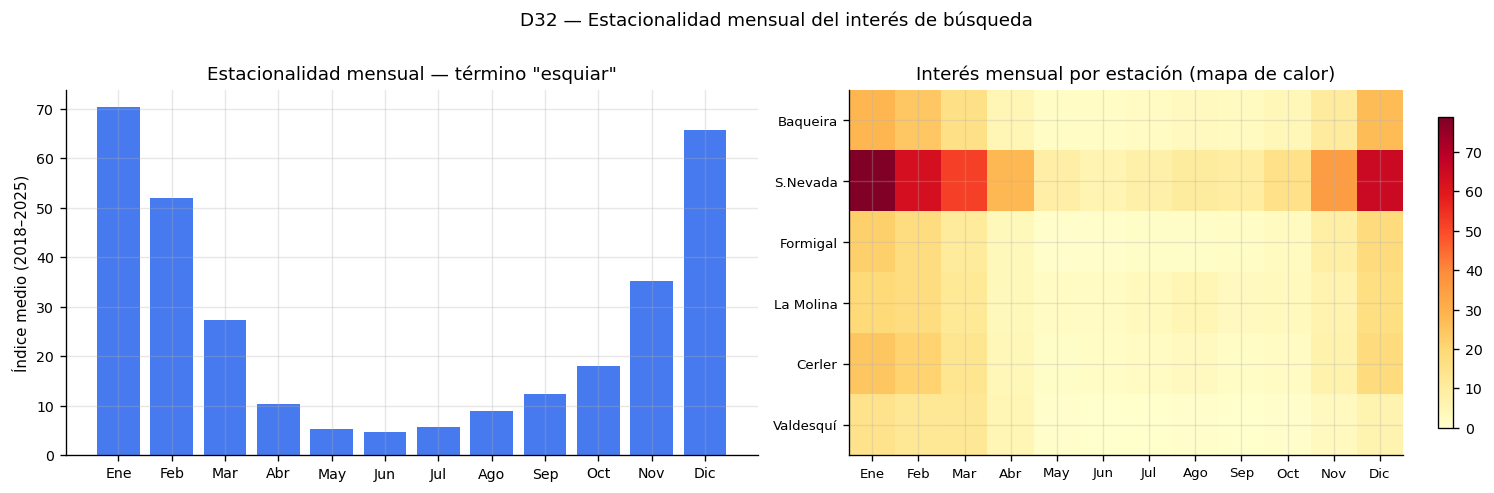

  ✓ D32_gtrends_estacionalidad.png


In [27]:
# D32 — Estacionalidad mensual del interés ────────────────────────────────────
gt_mes = gt.groupby('mes')[['gt_esquiar','gt_baqueira','gt_sierra_nevada',
                             'gt_formigal','gt_la_molina']].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Términos generales por mes
axes[0].bar(MESES, gt.groupby('mes')['gt_esquiar'].mean().values, color=C1, alpha=0.85)
axes[0].set_ylabel('Índice medio (2018–2025)')
axes[0].set_title('Estacionalidad mensual — término "esquiar"')

# Estaciones por mes (heatmap simple)
est_mes_cols = [c for c in ['gt_baqueira','gt_sierra_nevada','gt_formigal',
                             'gt_la_molina','gt_cerler','gt_valdesque'] if c in gt.columns]
est_mes_labels = ['Baqueira','S.Nevada','Formigal','La Molina','Cerler','Valdesquí']
mat = gt.groupby('mes')[est_mes_cols].mean().T.values
im = axes[1].imshow(mat, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=axes[1], shrink=0.85)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(MESES, fontsize=8)
axes[1].set_yticks(range(len(est_mes_cols)))
axes[1].set_yticklabels(est_mes_labels[:len(est_mes_cols)], fontsize=8)
axes[1].set_title('Interés mensual por estación (mapa de calor)')

plt.suptitle('D32 — Estacionalidad mensual del interés de búsqueda', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'D32_gtrends_estacionalidad')

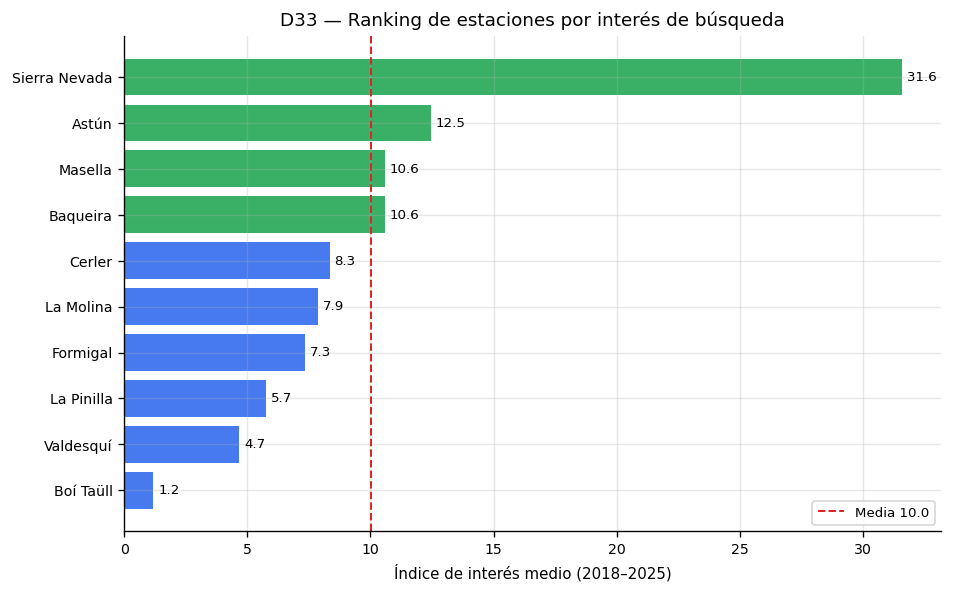

  ✓ D33_gtrends_ranking_estaciones.png


In [28]:
# D33 — Ranking de estaciones por interés medio ───────────────────────────────
gt_est_cols = ['gt_baqueira','gt_sierra_nevada','gt_formigal','gt_valdesque',
               'gt_la_molina','gt_cerler','gt_boi_taull','gt_masella','gt_astun','gt_la_pinilla']
gt_labels_map = {
    'gt_baqueira':'Baqueira','gt_sierra_nevada':'Sierra Nevada','gt_formigal':'Formigal',
    'gt_valdesque':'Valdesquí','gt_la_molina':'La Molina','gt_cerler':'Cerler',
    'gt_boi_taull':'Boí Taüll','gt_masella':'Masella','gt_astun':'Astún','gt_la_pinilla':'La Pinilla'
}
medias_gt = {gt_labels_map[c]: gt[c].mean() for c in gt_est_cols if c in gt.columns}
medias_gt_s = dict(sorted(medias_gt.items(), key=lambda x: x[1]))
media_global = np.mean(list(medias_gt_s.values()))

fig, ax = plt.subplots(figsize=(8, 5))
colores_r = [C2 if v >= media_global else C1 for v in medias_gt_s.values()]
ax.barh(list(medias_gt_s.keys()), list(medias_gt_s.values()), color=colores_r, alpha=0.85)
ax.axvline(media_global, color=C3, linestyle='--', linewidth=1.2,
           label=f'Media {media_global:.1f}')
for i, v in enumerate(medias_gt_s.values()):
    ax.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=8)
ax.set_xlabel('Índice de interés medio (2018–2025)')
ax.set_title('D33 — Ranking de estaciones por interés de búsqueda')
ax.legend(fontsize=8)
plt.tight_layout()
save(fig, 'D33_gtrends_ranking_estaciones')

Meses con pico de búsquedas (umbral 50.7): 19
     fecha  gt_esquiar  gt_baqueira  gt_sierra_nevada
2018-01-01          73           44                51
2018-02-01          66           46                47
2018-12-01          52           36                69
2019-01-01          62           25                87
2019-02-01          56           10                83
2019-12-01          63           13                81
2020-01-01          64           13                99
2021-12-01          77           34                71
2022-01-01          86           28                85
2022-02-01          56           34                69
2022-12-01          66            1                72
2023-01-01          77           13                97
2023-02-01          65           24                82
2023-12-01          65           50                48
2024-01-01          76           49                77
2024-12-01          81           45                48
2025-01-01          76           48 

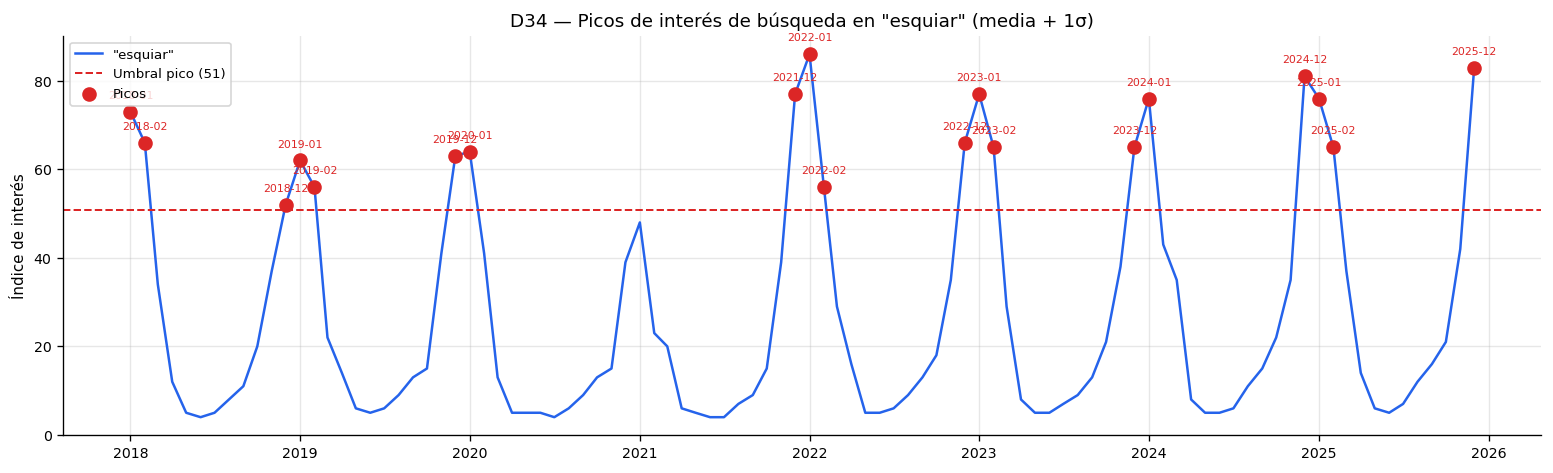

  ✓ D34_gtrends_picos_interes.png


In [29]:
# D34 — Identificación de picos de interés ────────────────────────────────────
# Picos = meses donde gt_esquiar supera media + 1 std
umbral = gt['gt_esquiar'].mean() + gt['gt_esquiar'].std()
picos = gt[gt['gt_esquiar'] >= umbral].copy()
print(f'Meses con pico de búsquedas (umbral {umbral:.1f}): {len(picos)}')
print(picos[['fecha','gt_esquiar','gt_baqueira','gt_sierra_nevada']].to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(gt['fecha'], gt['gt_esquiar'], '-', color=C1, linewidth=1.5, label='"esquiar"')
ax.axhline(umbral, color=C3, linestyle='--', linewidth=1.2, label=f'Umbral pico ({umbral:.0f})')
ax.scatter(picos['fecha'], picos['gt_esquiar'], color=C3, s=60, zorder=5, label='Picos')
for _, row in picos.iterrows():
    ax.annotate(row['fecha'].strftime('%Y-%m'), (row['fecha'], row['gt_esquiar']),
                fontsize=6.5, xytext=(0, 8), textcoords='offset points', ha='center', color=C3)
ax.set_ylabel('Índice de interés')
ax.set_title('D34 — Picos de interés de búsqueda en "esquiar" (media + 1σ)')
ax.legend(fontsize=8)
plt.tight_layout()
save(fig, 'D34_gtrends_picos_interes')

---
## BLOQUE E — Encuesta (dataset independiente)

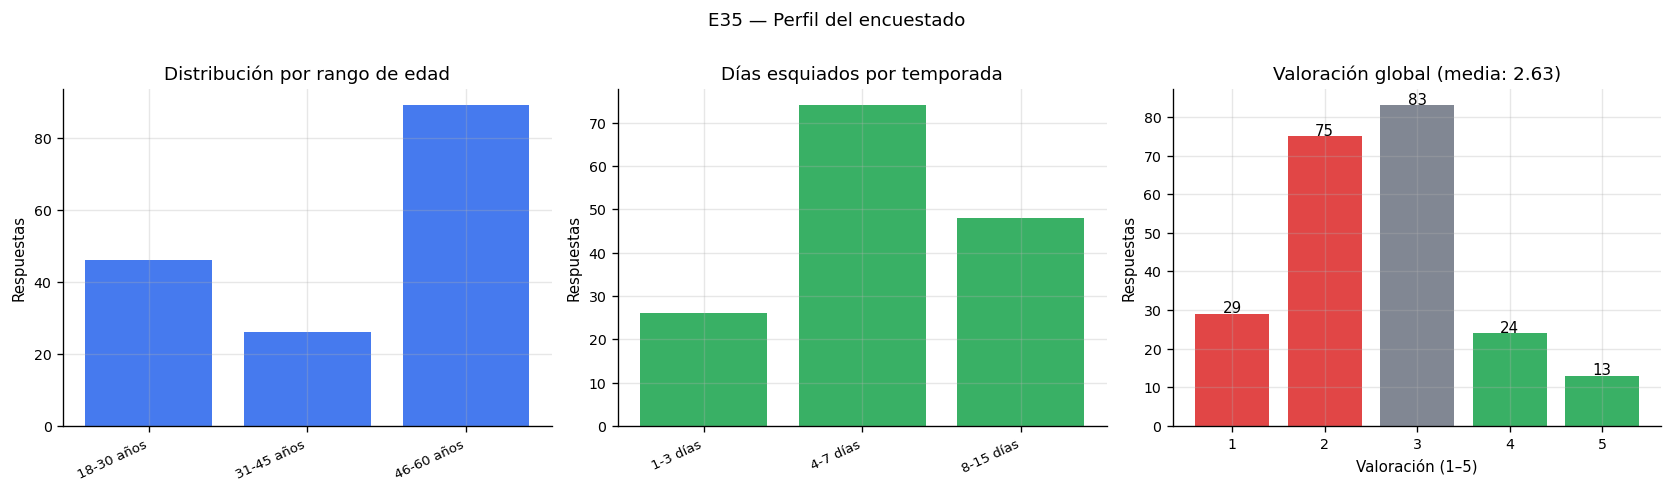

  ✓ E35_perfil_encuestado.png


In [30]:
# E35 — Perfil del encuestado ─────────────────────────────────────────────────
orden_edad  = ['18-30 años','31-45 años','46-60 años','61-75 años','Más de 75 años']
orden_dias  = ['1-3 días','4-7 días','8-15 días','Más de 15 días']
orden_hora  = ['Antes de las 8:00','Entre 8:00 y 9:00','Entre 9:00 y 10:00','Después de las 10:00']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Edad
ed = enc['edad_rango'].value_counts().reindex([e for e in orden_edad if e in enc['edad_rango'].values])
axes[0].bar(range(len(ed)), ed.values, color=C1, alpha=0.85)
axes[0].set_xticks(range(len(ed)))
axes[0].set_xticklabels(ed.index, rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Respuestas')
axes[0].set_title('Distribución por rango de edad')

# Días temporada
dd = enc['dias_temporada_limpia'].value_counts().reindex(
    [d for d in orden_dias if d in enc['dias_temporada_limpia'].dropna().values]).dropna()
axes[1].bar(range(len(dd)), dd.values, color=C2, alpha=0.85)
axes[1].set_xticks(range(len(dd)))
axes[1].set_xticklabels(dd.index, rotation=25, ha='right', fontsize=8)
axes[1].set_ylabel('Respuestas')
axes[1].set_title('Días esquiados por temporada')

# Valoración
val = enc['valoracion'].value_counts().sort_index()
colores_val = [C3 if v <= 2 else CGRIS if v == 3 else C2 for v in val.index]
axes[2].bar(val.index.astype(str), val.values, color=colores_val, alpha=0.85)
axes[2].set_xlabel('Valoración (1–5)')
axes[2].set_ylabel('Respuestas')
axes[2].set_title(f'Valoración global (media: {enc["valoracion"].mean():.2f})')
for i, v in enumerate(val.values):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontsize=9)

plt.suptitle('E35 — Perfil del encuestado', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'E35_perfil_encuestado')

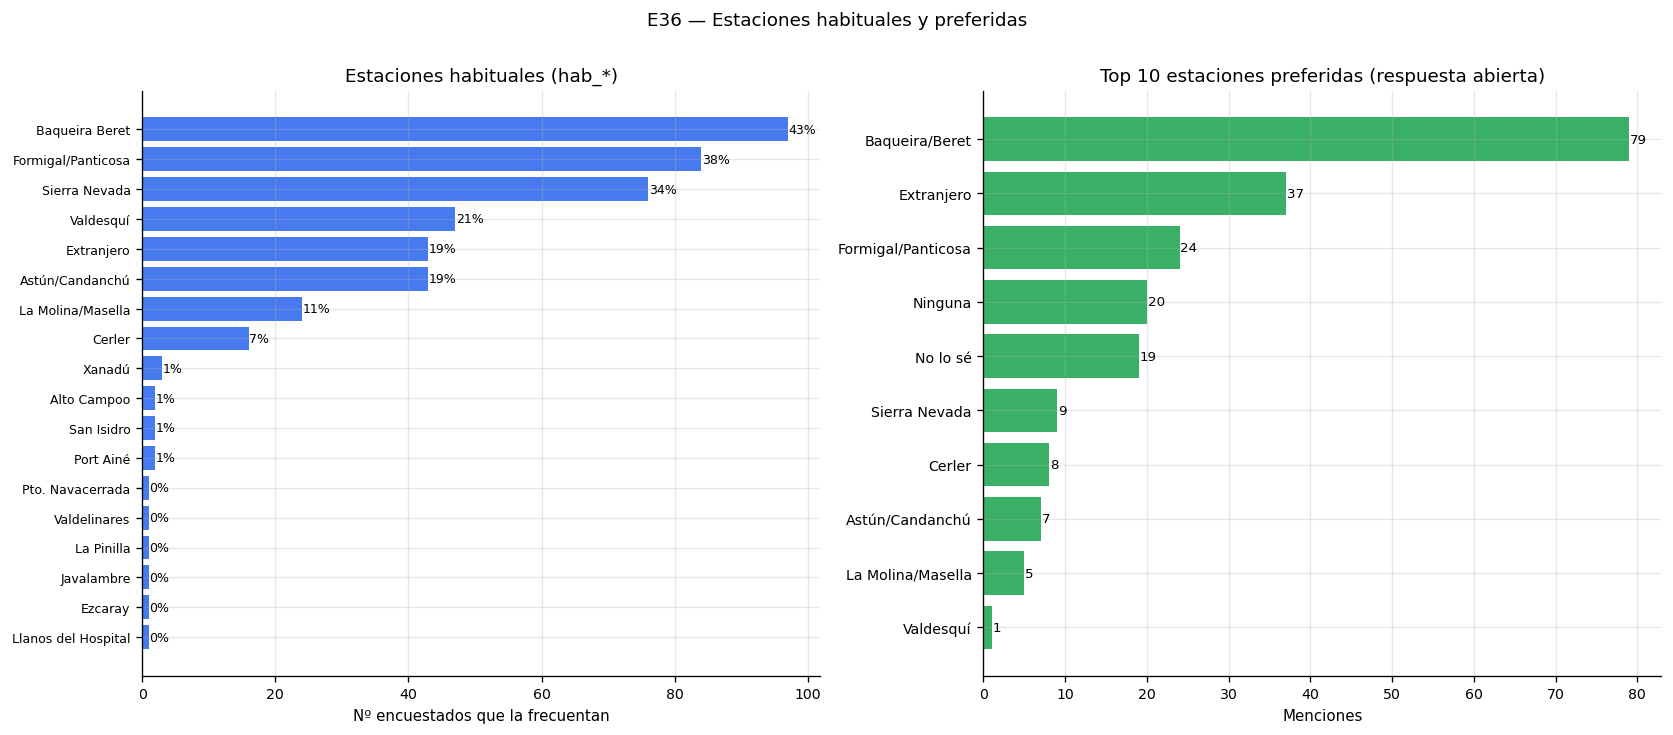

  ✓ E36_estaciones_visitadas.png


In [31]:
# E36 — Estaciones habituales (columnas hab_*) ─────────────────────────────────
hab_cols = [c for c in enc.columns if c.startswith('hab_')]
hab_labels = {
    'hab_baqueira_beret':'Baqueira Beret','hab_formigal_panticosa':'Formigal/Panticosa',
    'hab_astun_candanchu':'Astún/Candanchú','hab_sierra_nevada':'Sierra Nevada',
    'hab_valdesqui':'Valdesquí','hab_la_molina_masella':'La Molina/Masella',
    'hab_cerler':'Cerler','hab_la_pinilla':'La Pinilla','hab_alto_campoo':'Alto Campoo',
    'hab_javalambre':'Javalambre','hab_san_isidro':'San Isidro',
    'hab_puerto_navacerrada':'Pto. Navacerrada','hab_extranjero':'Extranjero',
    'hab_xanadu':'Xanadú','hab_ezcaray':'Ezcaray','hab_aramon':'Aramón',
    'hab_navafria':'Navafría','hab_llanos_hospital':'Llanos del Hospital',
    'hab_port_aine':'Port Ainé','hab_valdelinares':'Valdelinares',
}
frec = {hab_labels.get(c, c.replace('hab_','').title()): enc[c].sum()
        for c in hab_cols if enc[c].sum() > 0}
frec_s = dict(sorted(frec.items(), key=lambda x: x[1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(list(frec_s.keys()), list(frec_s.values()), color=C1, alpha=0.85)
for i, v in enumerate(frec_s.values()):
    pct = v / len(enc) * 100
    axes[0].text(v + 0.1, i, f'{pct:.0f}%', va='center', fontsize=7.5)
axes[0].set_xlabel('Nº encuestados que la frecuentan')
axes[0].set_title('Estaciones habituales (hab_*)')
axes[0].tick_params(axis='y', labelsize=7.5)

mejor = enc['mejor_estacion_norm'].value_counts().head(10).sort_values()
axes[1].barh(mejor.index, mejor.values, color=C2, alpha=0.85)
for i, v in enumerate(mejor.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=8)
axes[1].set_xlabel('Menciones')
axes[1].set_title('Top 10 estaciones preferidas (respuesta abierta)')

plt.suptitle('E36 — Estaciones habituales y preferidas', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'E36_estaciones_visitadas')

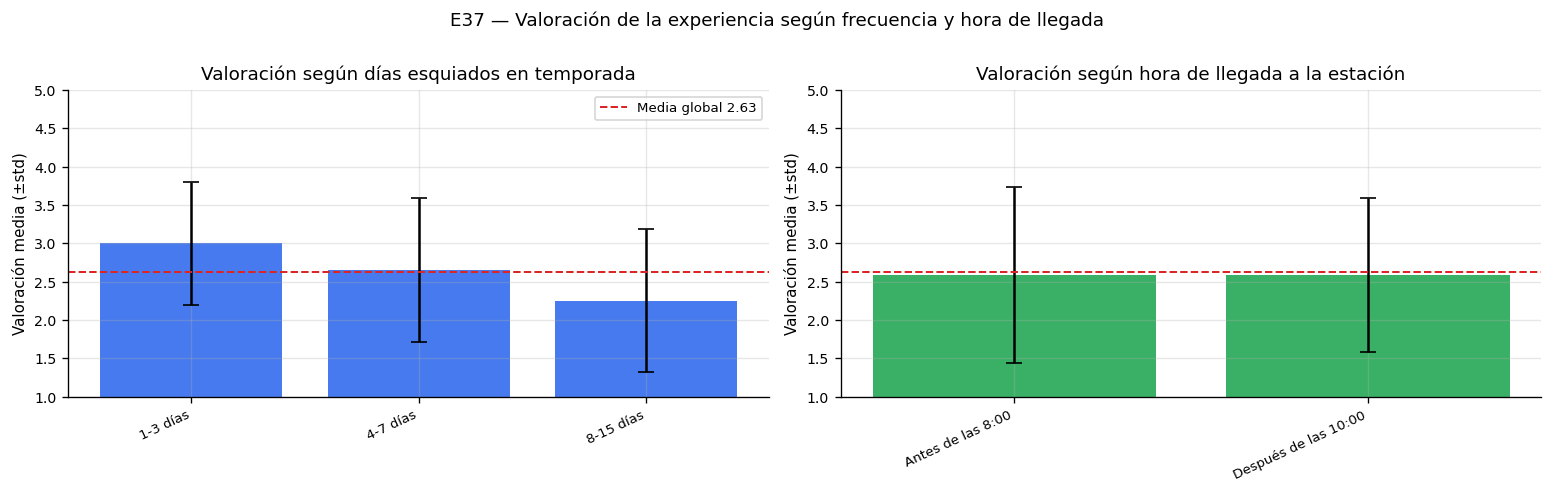

  ✓ E37_valoracion_experiencia.png


In [32]:
# E37 — Valoración de la experiencia según frecuencia de uso ──────────────────
orden_dias2 = ['1-3 días','4-7 días','8-15 días','Más de 15 días']
val_dias = enc.groupby('dias_temporada_limpia')['valoracion'].agg(['mean','std']).reindex(
    [d for d in orden_dias2 if d in enc['dias_temporada_limpia'].dropna().values]).dropna()

orden_hora2 = ['Antes de las 8:00','Entre 8:00 y 9:00','Entre 9:00 y 10:00','Después de las 10:00']
val_hora = enc.groupby('hora_llegada')['valoracion'].agg(['mean','std']).reindex(
    [h for h in orden_hora2 if h in enc['hora_llegada'].dropna().values]).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(len(val_dias)), val_dias['mean'], yerr=val_dias['std'],
            color=C1, alpha=0.85, capsize=5)
axes[0].axhline(enc['valoracion'].mean(), color=C3, linestyle='--', linewidth=1.2,
                label=f'Media global {enc["valoracion"].mean():.2f}')
axes[0].set_xticks(range(len(val_dias)))
axes[0].set_xticklabels(val_dias.index, rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Valoración media (±std)')
axes[0].set_ylim(1, 5)
axes[0].set_title('Valoración según días esquiados en temporada')
axes[0].legend(fontsize=8)

axes[1].bar(range(len(val_hora)), val_hora['mean'], yerr=val_hora['std'],
            color=C2, alpha=0.85, capsize=5)
axes[1].axhline(enc['valoracion'].mean(), color=C3, linestyle='--', linewidth=1.2)
axes[1].set_xticks(range(len(val_hora)))
axes[1].set_xticklabels(val_hora.index, rotation=25, ha='right', fontsize=8)
axes[1].set_ylabel('Valoración media (±std)')
axes[1].set_ylim(1, 5)
axes[1].set_title('Valoración según hora de llegada a la estación')

plt.suptitle('E37 — Valoración de la experiencia según frecuencia y hora de llegada', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'E37_valoracion_experiencia')

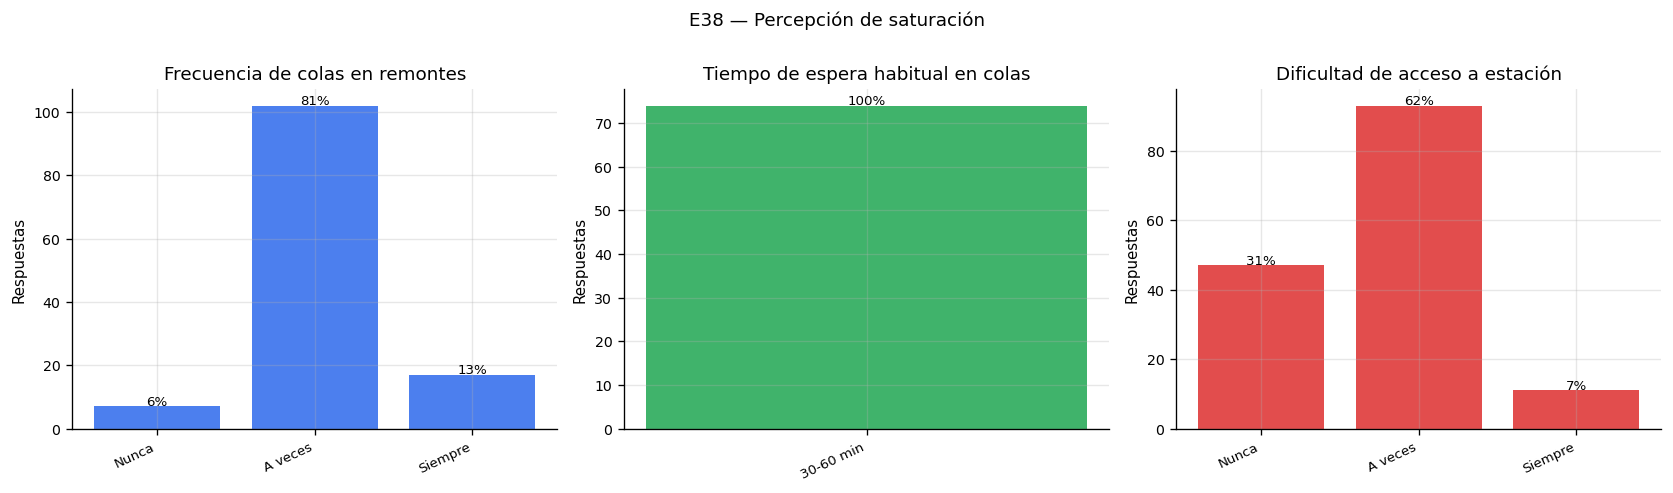

  ✓ E38_percepcion_saturacion.png


In [33]:
# E38 — Percepción de saturación / principal problema ─────────────────────────
orden_colas  = ['Nunca','Raramente','A veces','Siempre']
orden_tcolas = ['< 15 min','15-30 min','30-60 min','> 60 min']
orden_dif    = ['Nunca','Raramente','A veces','Siempre']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, orden, titulo, color) in zip(axes, [
    ('colas',            orden_colas,  'Frecuencia de colas en remontes',   C1),
    ('tiempo_colas',     orden_tcolas, 'Tiempo de espera habitual en colas', C2),
    ('dificultad_acceso',orden_dif,    'Dificultad de acceso a estación',    C3),
]):
    datos = enc[col].value_counts().reindex(
        [o for o in orden if o in enc[col].dropna().values]).dropna()
    total = datos.sum()
    ax.bar(range(len(datos)), datos.values, color=color, alpha=0.82)
    ax.set_xticks(range(len(datos)))
    ax.set_xticklabels(datos.index, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Respuestas')
    ax.set_title(titulo)
    for i, v in enumerate(datos.values):
        ax.text(i, v + 0.3, f'{v/total*100:.0f}%', ha='center', fontsize=8)

plt.suptitle('E38 — Percepción de saturación', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'E38_percepcion_saturacion')

Encuestados que usarían la app: 100.0%


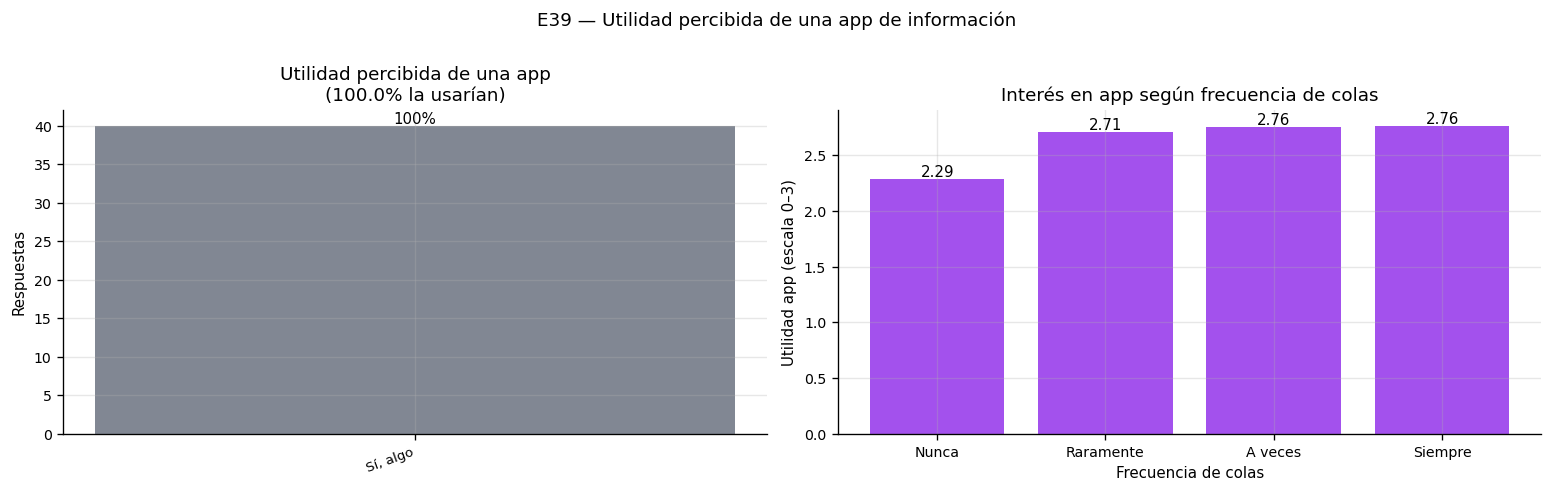

  ✓ E39_utilidad_app.png


In [34]:
# E39 — Utilidad percibida de una app con información en tiempo real ───────────
orden_app = ['No, no la usaría','Posiblemente','Sí, algo','Sí, bastante']
app_dist = enc['utilidad_app'].value_counts().reindex(
    [o for o in orden_app if o in enc['utilidad_app'].dropna().values]).dropna()
total = app_dist.sum()
usaria_pct = app_dist[app_dist.index.isin(['Sí, algo','Sí, bastante'])].sum() / total * 100
print(f'Encuestados que usarían la app: {usaria_pct:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colores_app = [CGRIS, CGRIS, C1, C2]
bars = axes[0].bar(range(len(app_dist)), app_dist.values,
                   color=colores_app[:len(app_dist)], alpha=0.85)
axes[0].set_xticks(range(len(app_dist)))
axes[0].set_xticklabels(app_dist.index, rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Respuestas')
axes[0].set_title(f'Utilidad percibida de una app\n({usaria_pct:.1f}% la usarían)')
for bar, v in zip(bars, app_dist.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3,
                 f'{v/total*100:.0f}%', ha='center', fontsize=9)

# Utilidad app por frecuencia de colas (escala ordinal)
app_colas = enc.groupby('colas_escala')['utilidad_app_escala'].mean()
etiq_colas = {0:'Nunca',1:'Raramente',2:'A veces',3:'Siempre'}
axes[1].bar([etiq_colas.get(i,str(i)) for i in app_colas.index], app_colas.values,
            color=C4, alpha=0.85)
axes[1].set_ylabel('Utilidad app (escala 0–3)')
axes[1].set_xlabel('Frecuencia de colas')
axes[1].set_title('Interés en app según frecuencia de colas')
for i, v in enumerate(app_colas.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('E39 — Utilidad percibida de una app de información', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'E39_utilidad_app')

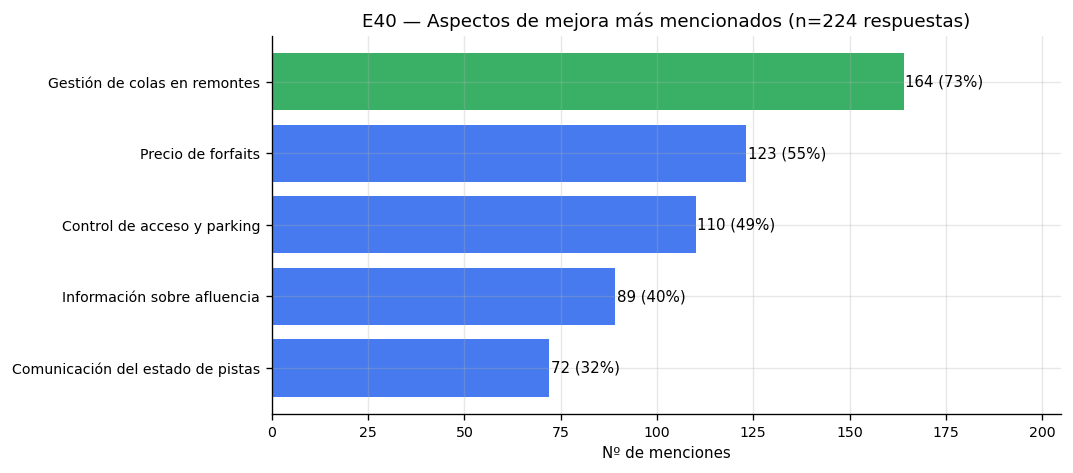

  ✓ E40_mejoras_sugeridas.png


In [35]:
# E40 — Aspectos de mejora más mencionados (text mining por categorías) ────────
# mejoras_sugeridas es una columna de listas separadas por comas
categorias = [
    'Gestión de colas en remontes',
    'Control de acceso y parking',
    'Información sobre afluencia',
    'Precio de forfaits',
    'Comunicación del estado de pistas',
]
conteos = {}
for cat in categorias:
    conteos[cat] = enc['mejoras_sugeridas'].dropna().str.contains(cat, regex=False).sum()

conteos_s = dict(sorted(conteos.items(), key=lambda x: x[1]))
total_resp = enc['mejoras_sugeridas'].notna().sum()

fig, ax = plt.subplots(figsize=(9, 4))
colores_m = [C2 if v == max(conteos_s.values()) else C1 for v in conteos_s.values()]
bars = ax.barh(list(conteos_s.keys()), list(conteos_s.values()),
               color=colores_m, alpha=0.85)
for bar, v in zip(bars, conteos_s.values()):
    pct = v / total_resp * 100
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v} ({pct:.0f}%)', va='center', fontsize=9)
ax.set_xlabel('Nº de menciones')
ax.set_title(f'E40 — Aspectos de mejora más mencionados (n={total_resp} respuestas)')
ax.set_xlim(0, max(conteos_s.values()) * 1.25)
ax.tick_params(axis='y', labelsize=8.5)
plt.tight_layout()
save(fig, 'E40_mejoras_sugeridas')

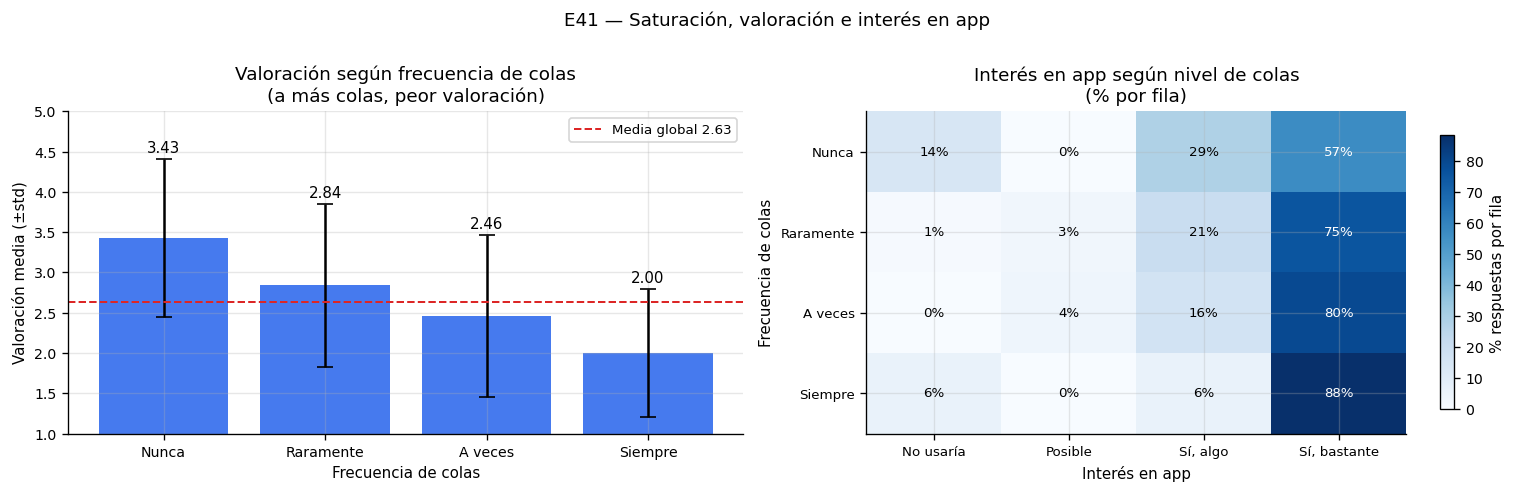

  ✓ E41_saturacion_valoracion_app.png


In [36]:
# E41 — Relación entre saturación, valoración e interés en app ────────────────
# Insight clave: quienes sufren más colas valoran peor y quieren más la app
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Valoración media según nivel de colas (ordinal)
val_colas = enc.groupby('colas_escala')['valoracion'].agg(['mean','std'])
etiq_c    = {0:'Nunca',1:'Raramente',2:'A veces',3:'Siempre'}
axes[0].bar([etiq_c[i] for i in val_colas.index], val_colas['mean'],
            yerr=val_colas['std'], color=C1, alpha=0.85, capsize=5)
axes[0].axhline(enc['valoracion'].mean(), color=C3, linestyle='--', linewidth=1.2,
                label=f'Media global {enc["valoracion"].mean():.2f}')
axes[0].set_xlabel('Frecuencia de colas')
axes[0].set_ylabel('Valoración media (±std)')
axes[0].set_ylim(1, 5)
axes[0].set_title('Valoración según frecuencia de colas\n(a más colas, peor valoración)')
axes[0].legend(fontsize=8)
for i, (idx, row) in enumerate(val_colas.iterrows()):
    axes[0].text(i, row['mean'] + row['std'] + 0.08, f'{row["mean"]:.2f}', ha='center', fontsize=9)

# Heatmap: colas × utilidad_app
cross = enc.groupby(['colas_escala','utilidad_app_escala']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
im = axes[1].imshow(cross_pct.values, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=axes[1], label='% respuestas por fila', shrink=0.85)
axes[1].set_xticks(range(cross_pct.shape[1]))
axes[1].set_xticklabels(['No usaría','Posible','Sí, algo','Sí, bastante'], fontsize=8)
axes[1].set_yticks(range(cross_pct.shape[0]))
axes[1].set_yticklabels([etiq_c[i] for i in cross_pct.index], fontsize=8)
axes[1].set_xlabel('Interés en app')
axes[1].set_ylabel('Frecuencia de colas')
axes[1].set_title('Interés en app según nivel de colas\n(% por fila)')
for i in range(cross_pct.shape[0]):
    for j in range(cross_pct.shape[1]):
        axes[1].text(j, i, f'{cross_pct.values[i,j]:.0f}%',
                     ha='center', va='center', fontsize=8,
                     color='white' if cross_pct.values[i,j] > 40 else 'black')

plt.suptitle('E41 — Saturación, valoración e interés en app', fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'E41_saturacion_valoracion_app')

---
## BLOQUE F — Plantillas de modelización
*(Ejecutar después de ajustar los modelos. Las celdas generan las figuras usando variables que deberás rellenar con tus resultados.)*

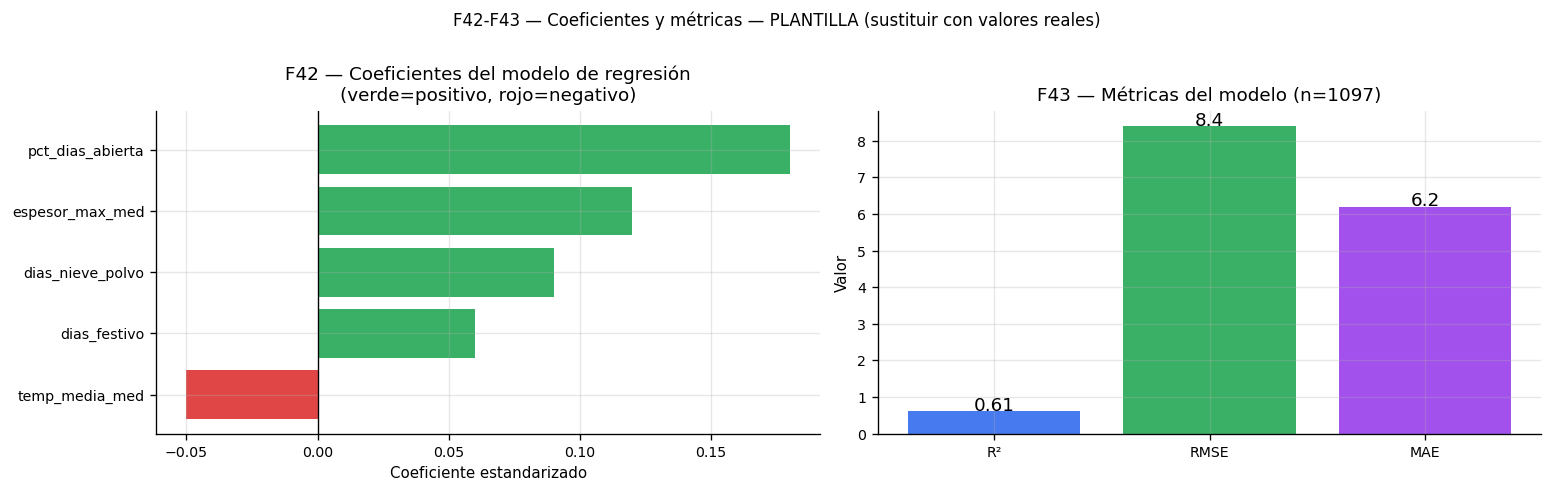

  ✓ F42_F43_regresion_coefs_metricas.png


In [37]:
# F42-F43 — Coeficientes y métricas del modelo de regresión ───────────────────
# RELLENAR: sustituir con los valores reales del modelo

# Ejemplo de estructura esperada:
reg_coefs  = {'pct_dias_abierta':0.18,'espesor_max_med':0.12,'dias_nieve_polvo':0.09,
              'dias_festivo':0.06,'temp_media_med':-0.05}  # ← sustituir
reg_metricas = {'R²':0.61,'RMSE':8.4,'MAE':6.2,'n':1097}  # ← sustituir

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# F42 Coeficientes
coefs_s = dict(sorted(reg_coefs.items(), key=lambda x: abs(x[1])))
colores_c = [C2 if v > 0 else C3 for v in coefs_s.values()]
axes[0].barh(list(coefs_s.keys()), list(coefs_s.values()), color=colores_c, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Coeficiente estandarizado')
axes[0].set_title('F42 — Coeficientes del modelo de regresión\n(verde=positivo, rojo=negativo)')

# F43 Métricas
met_keys = list(reg_metricas.keys())[:-1]  # sin n
met_vals = [reg_metricas[k] for k in met_keys]
axes[1].bar(met_keys, met_vals, color=[C1,C2,C4], alpha=0.85)
for i, v in enumerate(met_vals):
    axes[1].text(i, v + 0.02, f'{v}', ha='center', fontsize=11)
axes[1].set_ylabel('Valor')
axes[1].set_title(f'F43 — Métricas del modelo (n={reg_metricas["n"]})')

plt.suptitle('F42-F43 — Coeficientes y métricas — PLANTILLA (sustituir con valores reales)',
             fontsize=10, y=1.01)
plt.tight_layout()
save(fig, 'F42_F43_regresion_coefs_metricas')

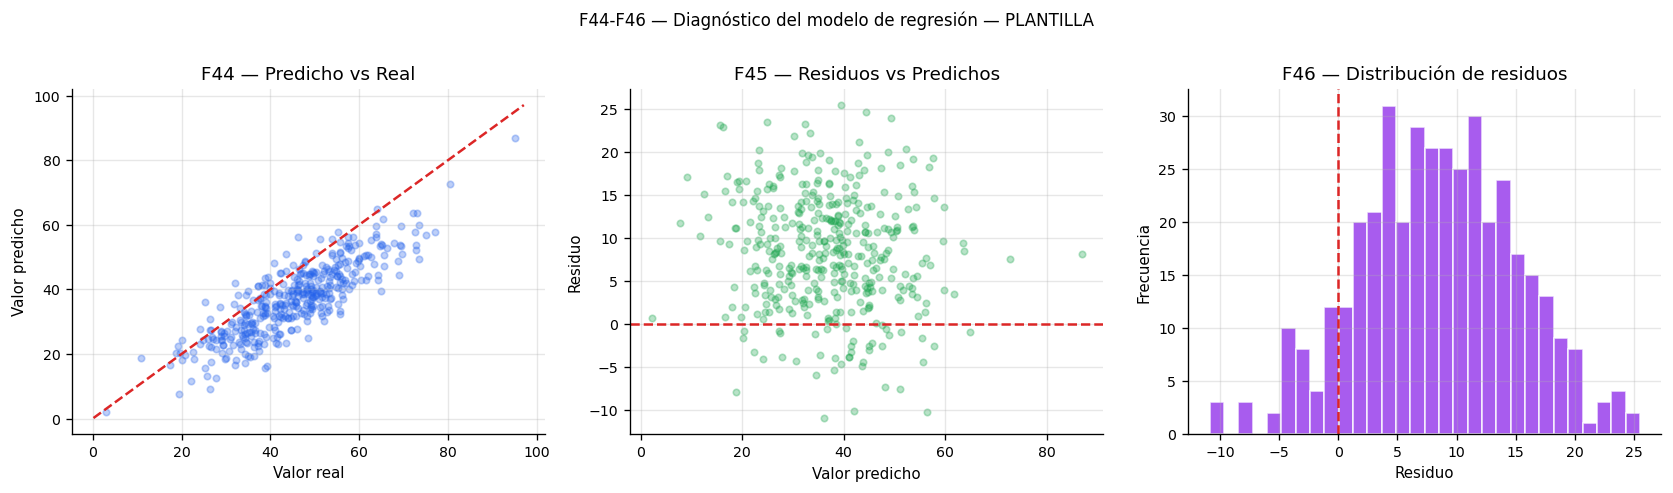

  ✓ F44_F46_regresion_diagnostico.png


In [38]:
# F44-F46 — Predicho vs real, residuos vs predichos, distribución residuos ────
# RELLENAR: y_real, y_pred con los vectores del modelo

np.random.seed(42)
y_real = np.random.normal(45, 13, 400)                        # ← sustituir
y_pred = y_real * 0.82 + np.random.normal(0, 6, 400)         # ← sustituir
residuos = y_real - y_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# F44 Predicho vs Real
axes[0].scatter(y_real, y_pred, alpha=0.3, s=15, color=C1)
lim = [min(y_real.min(), y_pred.min())-2, max(y_real.max(), y_pred.max())+2]
axes[0].plot(lim, lim, color=C3, linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title('F44 — Predicho vs Real')

# F45 Residuos vs Predichos
axes[1].scatter(y_pred, residuos, alpha=0.3, s=15, color=C2)
axes[1].axhline(0, color=C3, linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Valor predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('F45 — Residuos vs Predichos')

# F46 Distribución de residuos
axes[2].hist(residuos, bins=30, color=C4, alpha=0.8, edgecolor='white')
axes[2].axvline(0, color=C3, linewidth=1.5, linestyle='--')
axes[2].set_xlabel('Residuo')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('F46 — Distribución de residuos')

plt.suptitle('F44-F46 — Diagnóstico del modelo de regresión — PLANTILLA',
             fontsize=10, y=1.01)
plt.tight_layout()
save(fig, 'F44_F46_regresion_diagnostico')

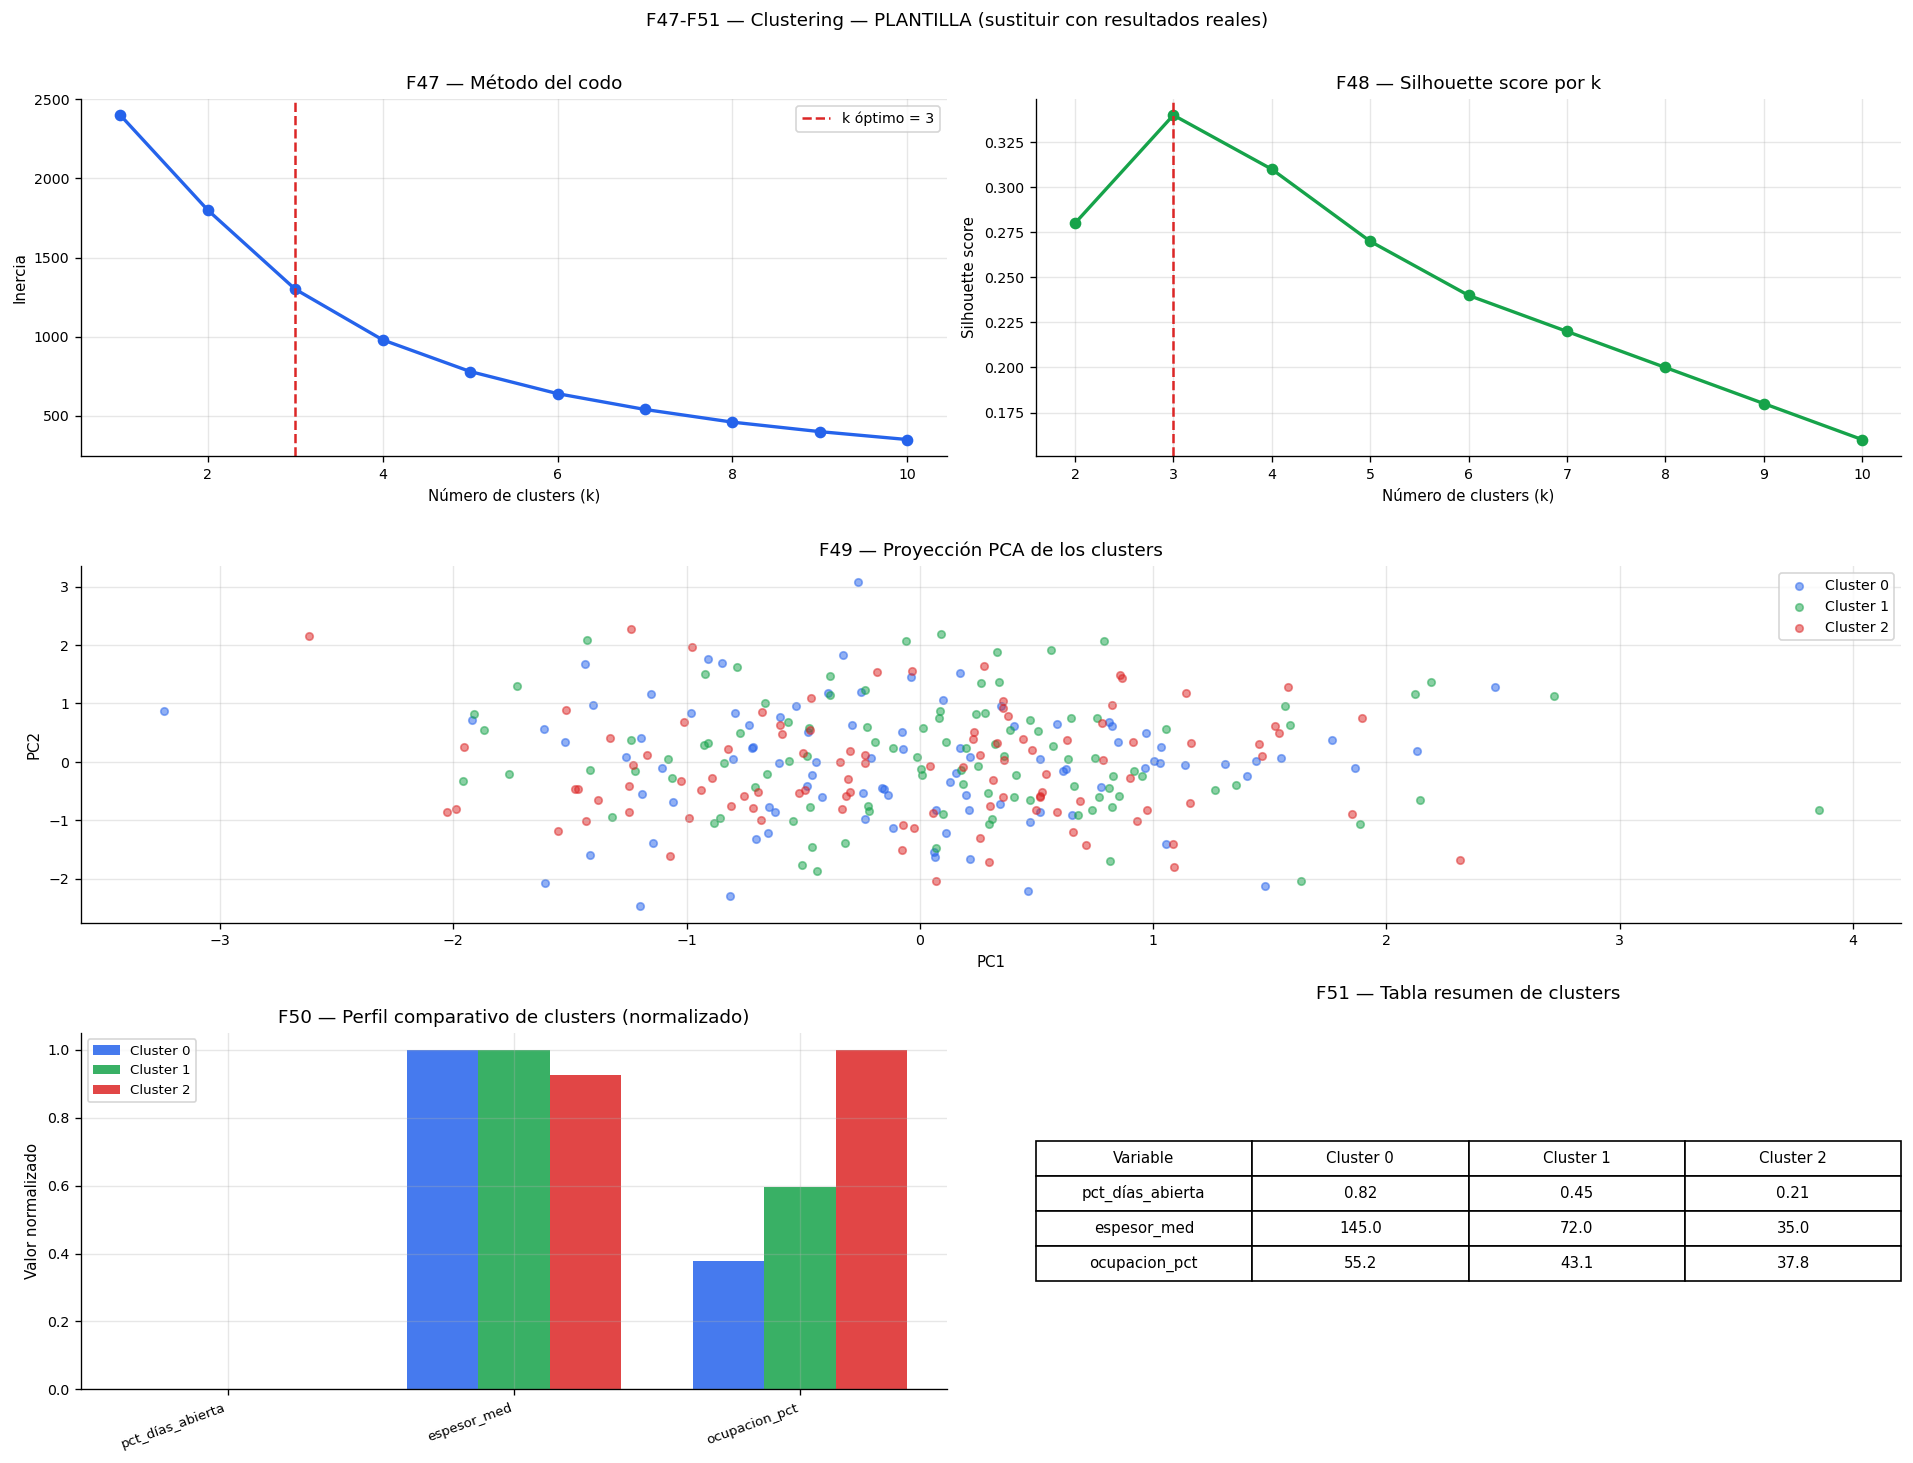

  ✓ F47_F51_clustering.png


In [39]:
# F47-F51 — Clustering: codo, silhouette, PCA, perfil, tabla ─────────────────
# RELLENAR: inertias, sil_scores, labels, pca_coords, cluster_profiles

np.random.seed(42)
# Plantilla: rellenar con valores reales
inertias   = [2400, 1800, 1300, 980, 780, 640, 540, 460, 400, 350]  # ← sustituir
sil_scores = [0,0.28,0.34,0.31,0.27,0.24,0.22,0.20,0.18,0.16]       # ← sustituir (k=1 sin valor)
k_opt = 3                                                              # ← sustituir
n = 300
pca_x = np.random.randn(n);  pca_y = np.random.randn(n)              # ← sustituir con PCA coords
labels = np.random.choice(k_opt, n)                                   # ← sustituir con cluster labels
cluster_profiles = pd.DataFrame({                                      # ← sustituir
    'Variable':['pct_días_abierta','espesor_med','ocupacion_pct'],
    'Cluster 0':[0.82, 145, 55.2],
    'Cluster 1':[0.45, 72,  43.1],
    'Cluster 2':[0.21, 35,  37.8],
})

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig)

# F47 Método del codo
ax47 = fig.add_subplot(gs[0,0])
ax47.plot(range(1, len(inertias)+1), inertias, 'o-', color=C1, linewidth=2)
ax47.axvline(k_opt, color=C3, linestyle='--', linewidth=1.5, label=f'k óptimo = {k_opt}')
ax47.set_xlabel('Número de clusters (k)')
ax47.set_ylabel('Inercia')
ax47.set_title('F47 — Método del codo')
ax47.legend()

# F48 Silhouette
ax48 = fig.add_subplot(gs[0,1])
ax48.plot(range(2, len(sil_scores)+1), sil_scores[1:], 'o-', color=C2, linewidth=2)
ax48.axvline(k_opt, color=C3, linestyle='--', linewidth=1.5)
ax48.set_xlabel('Número de clusters (k)')
ax48.set_ylabel('Silhouette score')
ax48.set_title('F48 — Silhouette score por k')

# F49 PCA clusters
ax49 = fig.add_subplot(gs[1,:])
colors_cl = [C1, C2, C3, C4]
for k in range(k_opt):
    mask = labels == k
    ax49.scatter(pca_x[mask], pca_y[mask], s=20, alpha=0.5,
                 color=colors_cl[k], label=f'Cluster {k}')
ax49.set_xlabel('PC1')
ax49.set_ylabel('PC2')
ax49.set_title('F49 — Proyección PCA de los clusters')
ax49.legend()

# F50 Perfil comparativo de clusters
ax50 = fig.add_subplot(gs[2,0])
cluster_cols = [c for c in cluster_profiles.columns if c.startswith('Cluster')]
x_pos = np.arange(len(cluster_profiles))
w_cl = 0.25
for i, col in enumerate(cluster_cols):
    vals = cluster_profiles[col].astype(float)
    vals_norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)  # normalizar para comparar
    ax50.bar(x_pos + i*w_cl, vals_norm, w_cl, label=col, color=colors_cl[i], alpha=0.85)
ax50.set_xticks(x_pos + w_cl)
ax50.set_xticklabels(cluster_profiles['Variable'], rotation=20, ha='right', fontsize=8)
ax50.set_ylabel('Valor normalizado')
ax50.set_title('F50 — Perfil comparativo de clusters (normalizado)')
ax50.legend(fontsize=8)

# F51 Tabla resumen clusters
ax51 = fig.add_subplot(gs[2,1])
ax51.axis('off')
tabla = cluster_profiles.round(2)
t = ax51.table(cellText=tabla.values, colLabels=tabla.columns,
               cellLoc='center', loc='center')
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1, 1.6)
ax51.set_title('F51 — Tabla resumen de clusters', pad=20)

plt.suptitle('F47-F51 — Clustering — PLANTILLA (sustituir con resultados reales)',
             fontsize=11, y=1.01)
plt.tight_layout()
save(fig, 'F47_F51_clustering')

---
## Compresión y descarga

In [40]:
# ── Comprimir carpeta y descargar ─────────────────────────────────────────────
zip_path = '/content/graficas_tfg.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir(OUT)):
        if fname.endswith('.png'):
            zf.write(os.path.join(OUT, fname), arcname=fname)

n_files = len([f for f in os.listdir(OUT) if f.endswith('.png')])
size_mb = os.path.getsize(zip_path) / 1024 / 1024
print(f'ZIP generado: {zip_path}')
print(f'Archivos incluidos: {n_files}')
print(f'Tamaño: {size_mb:.1f} MB')

from google.colab import files
files.download(zip_path)

ZIP generado: /content/graficas_tfg.zip
Archivos incluidos: 36
Tamaño: 3.0 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>